# Laboratorio 7 – Perfiles y salario de la población asalariada según ENEIC con Spark

Este notebook estudia el salario mensual de la población asalariada de Guatemala con las bases de Personas de la Encuesta Nacional de Empleo e Ingresos Continua del Instituto Nacional de Estadística. Los cuatro trimestres de 2025 forman el conjunto de desarrollo y el primer trimestre de 2026 se prepara con las mismas reglas y se reserva para la evaluación final de los modelos supervisados.

## Verificación de entorno

Se comprueban la versión de Python, el intérprete, Java, los paquetes requeridos y la existencia de los cinco archivos de datos y sus diccionarios. Los nombres de los archivos se definen aquí una sola vez.

In [10]:
import importlib
import shutil
import subprocess
import sys
from pathlib import Path

print("Python    :", sys.version.split()[0])
print("Ejecutable:", sys.executable)

ruta_java = shutil.which("java")
if ruta_java is None:
    print("Java      : no encontrado en el PATH")
else:
    salida = subprocess.run([ruta_java, "-version"], capture_output=True, text=True)
    lineas = [l.strip() for l in (salida.stderr + salida.stdout).splitlines() if "version" in l.lower()]
    print("Java      :", lineas[0] if lineas else "version no identificada")

print("-" * 60)

PAQUETES = ["pyspark", "pandas", "numpy", "openpyxl", "matplotlib", "seaborn"]
for nombre in PAQUETES:
    try:
        modulo = importlib.import_module(nombre)
        print(f"{nombre:<11}", modulo.__version__)
    except ImportError:
        print(f"{nombre:<11}", "NO DISPONIBLE")

print("-" * 60)

# la raiz del proyecto es la carpeta que contiene a notebook
DIR_BASE = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
DIR_RAW = DIR_BASE / "data" / "raw"

# cada corte se identifica por el archivo publicado y no por la columna TRIMESTRE
CORTES = {
    "2025T1": ("I", 2025, 1),
    "2025T2": ("II", 2025, 2),
    "2025T3": ("III", 2025, 3),
    "2025T4": ("IV", 2025, 4),
    "2026T1": ("I", 2026, 1),
}
ARCHIVOS_ENEIC = {
    periodo: {
        "datos": f"BaseDatos_Personas_ENEIC_{romano}_{anio}.xlsx",
        "diccionario": f"Diccionario_Personas_ENEIC_{romano}_{anio}.xlsx",
        "anio": anio,
        "trimestre": trimestre,
    }
    for periodo, (romano, anio, trimestre) in CORTES.items()
}

for periodo, info in ARCHIVOS_ENEIC.items():
    for tipo in ["datos", "diccionario"]:
        ruta = DIR_RAW / info[tipo]
        estado = f"{ruta.stat().st_size / 1e6:6.1f} MB" if ruta.exists() else "FALTANTE"
        print(f"{periodo}  {info[tipo]:<42} {estado}")

Python    : 3.12.0
Ejecutable: c:\Users\andre\Desktop\Laboratorio7\.venv\Scripts\python.exe
Java      : java version "21.0.12" 2026-07-21 LTS
------------------------------------------------------------
pyspark     3.5.1
pandas      3.0.6
numpy       2.5.3
openpyxl    3.1.5
matplotlib  3.11.2
seaborn     0.13.2
------------------------------------------------------------
2025T1  BaseDatos_Personas_ENEIC_I_2025.xlsx         47.7 MB
2025T1  Diccionario_Personas_ENEIC_I_2025.xlsx        0.1 MB
2025T2  BaseDatos_Personas_ENEIC_II_2025.xlsx        16.9 MB
2025T2  Diccionario_Personas_ENEIC_II_2025.xlsx       0.1 MB
2025T3  BaseDatos_Personas_ENEIC_III_2025.xlsx       47.6 MB
2025T3  Diccionario_Personas_ENEIC_III_2025.xlsx      0.1 MB
2025T4  BaseDatos_Personas_ENEIC_IV_2025.xlsx        51.3 MB
2025T4  Diccionario_Personas_ENEIC_IV_2025.xlsx       0.1 MB
2026T1  BaseDatos_Personas_ENEIC_I_2026.xlsx         46.0 MB
2026T1  Diccionario_Personas_ENEIC_I_2026.xlsx        0.1 MB


## Configuración del proyecto

Rutas de datos procesados, figuras y modelos, particiones temporales y semilla. Los archivos originales permanecen sin cambios en data/raw.

In [11]:
DIR_PROCESADO = DIR_BASE / "data" / "processed"
DIR_FIGURAS = DIR_BASE / "figures"
DIR_MODELOS = DIR_BASE / "models"
for carpeta in [DIR_PROCESADO, DIR_FIGURAS, DIR_MODELOS]:
    carpeta.mkdir(parents=True, exist_ok=True)

INDICE_FIGURAS = DIR_FIGURAS / "indice_figuras.csv"
RUTA_METADATOS = DIR_PROCESADO / "metadatos_archivos.json"
RUTA_ANALITICA_2025 = DIR_PROCESADO / "eneic_2025_analitica.parquet"
RUTA_ANALITICA_2026 = DIR_PROCESADO / "eneic_2026_analitica.parquet"

PERIODOS_2025 = ["2025T1", "2025T2", "2025T3", "2025T4"]
PERIODOS_ENTRENAMIENTO = ["2025T1", "2025T2", "2025T3"]
PERIODO_VALIDACION = "2025T4"
PERIODO_PRUEBA = "2026T1"

# cambiar a True obliga a releer las hojas de calculo aunque ya existan los Parquet
FORZAR_CONVERSION = False
SEMILLA = 42

print("Datos procesados:", DIR_PROCESADO)
print("Figuras         :", DIR_FIGURAS)
print("Modelos         :", DIR_MODELOS)

Datos procesados: c:\Users\andre\Desktop\Laboratorio7\data\processed
Figuras         : c:\Users\andre\Desktop\Laboratorio7\figures
Modelos         : c:\Users\andre\Desktop\Laboratorio7\models


### Utilidades de figuras, tablas y estilo gráfico

Las figuras se guardan con un contador secuencial y se registran en indice_figuras.csv, que se reinicia en cada ejecución completa. Las tablas se muestran con separador de miles y decimales uniformes. La paleta es única para todo el cuaderno: azul para magnitudes, naranja para la serie de contraste, gris para referencias y un orden fijo de colores para los grupos.

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

COLOR_PRINCIPAL = "#2a78d6"
COLOR_CONTRASTE = "#eb6834"
COLOR_REFERENCIA = "#52514e"
PALETA_GRUPOS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

sns.set_theme(style="whitegrid", rc={"grid.color": "#e6e5e0", "axes.edgecolor": "#c3c2b7"})
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 10})
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)

if INDICE_FIGURAS.exists():
    INDICE_FIGURAS.unlink()
CONTADOR_FIGURAS = {"n": 0}


def guardar_figura(descripcion):
    """Guarda la figura activa con numeracion secuencial y la registra en el indice."""
    CONTADOR_FIGURAS["n"] += 1
    nombre = f"Figura{CONTADOR_FIGURAS['n']}.png"
    plt.savefig(DIR_FIGURAS / nombre, dpi=150, bbox_inches="tight")
    registro = pd.DataFrame([{"numero": CONTADOR_FIGURAS["n"], "archivo": nombre, "descripcion": descripcion}])
    registro.to_csv(INDICE_FIGURAS, mode="a", header=not INDICE_FIGURAS.exists(), index=False, encoding="utf-8")
    return nombre


COLUMNAS_IDENTIFICADOR = {"ANIO", "anio_archivo", "TRIMESTRE", "trimestre_calendario", "NUM_HOGAR", "NUM_PERSONA"}


def mostrar(tabla, decimales=2, vacio="Sin dato"):
    """Muestra una tabla con separador de miles, decimales uniformes y nulos explicitos."""
    if hasattr(tabla, "toPandas"):
        tabla = tabla.toPandas()
    salida = tabla.copy()
    for columna in salida.columns:
        serie = salida[columna]
        if columna in COLUMNAS_IDENTIFICADOR:
            salida[columna] = serie.map(lambda v: vacio if pd.isna(v) else str(int(v)))
        elif pd.api.types.is_bool_dtype(serie):
            salida[columna] = serie.map({True: "Sí", False: "No"})
        elif pd.api.types.is_integer_dtype(serie):
            salida[columna] = serie.map(lambda v: f"{v:,}")
        elif pd.api.types.is_float_dtype(serie):
            if isinstance(decimales, dict) and columna in decimales:
                n = decimales[columna]
            elif serie.dropna().apply(float.is_integer).all():
                n = 0
            else:
                n = decimales if isinstance(decimales, int) else 2
            salida[columna] = serie.map(lambda v, n=n: vacio if pd.isna(v) else f"{v:,.{n}f}")
        else:
            salida[columna] = serie.astype(object).where(serie.notna(), vacio)
    display(salida)


print("Utilidades de figuras y tablas listas")

Utilidades de figuras y tablas listas


### Sesión de Spark

Sesión local con todos los hilos disponibles. Se desactivan Arrow, que exige permisos adicionales y no aporta con tablas pequeñas, y las barras de progreso de Spark. Spark usa el mismo intérprete del notebook para sus procesos de Python.

In [13]:
import os

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T

# en Windows los procesos de Python de Spark deben usar el interprete del notebook
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = (
    SparkSession.builder
    .appName("Laboratorio7_ENEIC")
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.execution.arrow.pyspark.enabled", "false")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print("Spark:", spark.version)
print("Java :", spark.sparkContext._jvm.java.lang.System.getProperty("java.version"))
print("Hilos:", spark.sparkContext.defaultParallelism)

Spark: 3.5.1
Java : 21.0.12
Hilos: 8


## Ejercicio 1 – Carga, armonización y calidad de los datos

Se leen los diccionarios y los cinco archivos, se homologan tipos, se identifica la procedencia de cada registro, se unen los cortes de 2025 por nombre de columna, se miden los faltantes, se aplican los filtros de la población analítica y se verifica la unicidad de la clave. Los conjuntos de 2025 y 2026 se guardan por separado en Parquet.

### 1.1 – Variables seleccionadas y diccionario de códigos

Correspondencia entre columnas originales y nombres analíticos, y etiquetas de los códigos extraídas de los cinco diccionarios, con una verificación de que coinciden entre sí.

In [14]:
MAPA_COLUMNAS = {
    "P05D01": "salario_mensual",
    "P02A03": "edad",
    "P05C07A": "antiguedad_anios",
    "P05C07B": "antiguedad_meses",
    "P05H01A": "horas_semanales",
    "P03A03A": "nivel_educativo",
    "P05C16": "categoria_ocupacional",
    "DOMINIO": "dominio",
    "OCUPADOS": "ocupado",
}
COLUMNAS_AUDITORIA = ["NUM_HOGAR", "NUM_PERSONA", "FACTOR", "ANIO", "TRIMESTRE"]
COLUMNAS_ORIGEN = list(MAPA_COLUMNAS) + COLUMNAS_AUDITORIA

VARIABLES_NUMERICAS = ["salario_mensual", "edad", "antiguedad_anios", "antiguedad_meses", "horas_semanales", "FACTOR"]
VARIABLES_CODIGO = ["nivel_educativo", "categoria_ocupacional", "dominio", "ocupado"]
VARIABLES_ENTERAS = ["NUM_HOGAR", "NUM_PERSONA", "ANIO", "TRIMESTRE"]

mostrar(pd.DataFrame({"columna_original": list(MAPA_COLUMNAS) + COLUMNAS_AUDITORIA,
                      "nombre_analitico": list(MAPA_COLUMNAS.values()) + COLUMNAS_AUDITORIA}))

,columna_original,nombre_analitico
0,P05D01,salario_mensual
1,P02A03,edad
2,P05C07A,antiguedad_anios
3,P05C07B,antiguedad_meses
4,P05H01A,horas_semanales
5,P03A03A,nivel_educativo
6,P05C16,categoria_ocupacional
7,DOMINIO,dominio
8,OCUPADOS,ocupado
9,NUM_HOGAR,NUM_HOGAR


In [15]:
def leer_valores_diccionario(ruta):
    """Extrae la tabla de codigos y etiquetas de la seccion de valores de un diccionario."""
    hoja = pd.read_excel(ruta, header=None, dtype=str)
    inicio = hoja.index[hoja[0].astype(str).str.strip() == "Valores de variable"][0]
    valores = hoja.iloc[inicio + 2:, :3].copy()
    valores.columns = ["variable", "codigo", "etiqueta"]
    valores["variable"] = valores["variable"].ffill().str.strip()
    valores = valores.dropna(subset=["codigo"])
    valores["codigo"] = valores["codigo"].str.strip()
    valores["etiqueta"] = valores["etiqueta"].str.strip()
    return valores


def limpiar_etiqueta(texto):
    """Quita el signo de interrogacion final y normaliza mayusculas sostenidas."""
    texto = texto.strip().rstrip("?").strip()
    return texto.capitalize() if texto.isupper() else texto


VARIABLES_DICCIONARIO = {"P03A03A": "nivel_educativo", "P05C16": "categoria_ocupacional", "DOMINIO": "dominio", "OCUPADOS": "ocupado"}

catalogos = pd.concat(
    [leer_valores_diccionario(DIR_RAW / info["diccionario"]).assign(periodo_archivo=periodo)
     for periodo, info in ARCHIVOS_ENEIC.items()],
    ignore_index=True,
)
catalogos = catalogos[catalogos["variable"].isin(VARIABLES_DICCIONARIO)]

# un codigo es consistente si recibe la misma etiqueta en los cinco diccionarios
consistencia = catalogos.groupby(["variable", "codigo"]).agg(
    diccionarios=("periodo_archivo", "nunique"), etiquetas_distintas=("etiqueta", "nunique")
)
print("Codigos revisados                               :", len(consistencia))
print("Codigos presentes en los cinco diccionarios     :", int((consistencia["diccionarios"] == 5).sum()))
print("Codigos con etiquetas distintas entre diccionarios:", int((consistencia["etiquetas_distintas"] > 1).sum()))

Codigos revisados                               : 21
Codigos presentes en los cinco diccionarios     : 21
Codigos con etiquetas distintas entre diccionarios: 0


In [16]:
catalogo = catalogos[catalogos["periodo_archivo"] == "2025T1"].copy()
catalogo["etiqueta"] = catalogo["etiqueta"].map(limpiar_etiqueta)

ETIQUETAS = {
    VARIABLES_DICCIONARIO[variable]: dict(zip(grupo["codigo"], grupo["etiqueta"]))
    for variable, grupo in catalogo.groupby("variable")
}
CATEGORIAS_ASALARIADAS = ["1", "2", "3", "4"]
ETIQUETA_DESCONOCIDA = "DESCONOCIDO"

ORDEN_EDUCATIVO = [ETIQUETAS["nivel_educativo"][c] for c in sorted(ETIQUETAS["nivel_educativo"], key=int)]
ORDEN_OCUPACIONAL = [ETIQUETAS["categoria_ocupacional"][c] for c in CATEGORIAS_ASALARIADAS]
ORDEN_DOMINIO = [ETIQUETAS["dominio"][c] for c in sorted(ETIQUETAS["dominio"], key=int)]

mostrar(pd.DataFrame(
    [{"variable": v, "codigo": c, "etiqueta": e} for v, etiquetas in ETIQUETAS.items() for c, e in etiquetas.items()]
))

,variable,codigo,etiqueta
0,dominio,1,Urbano Metropolitano
1,dominio,2,Resto Urbano
2,dominio,3,Rural Nacional
3,ocupado,1,Población ocupada
4,nivel_educativo,0,Ninguno
5,nivel_educativo,1,Preprimaria
6,nivel_educativo,2,Primaria
7,nivel_educativo,3,Básico
8,nivel_educativo,4,Diversificado
9,nivel_educativo,5,Superior


### 1.2 – Lectura de las hojas de cálculo y esquema explícito

Cada variable se ubica por su nombre en el encabezado, no por su posición. Los valores numéricos pasan a punto flotante, los códigos a texto sin decimales y los identificadores a enteros, con un esquema de Spark declarado de forma explícita.

In [17]:
import json
import math
from collections import Counter

import openpyxl


def leer_hoja(ruta):
    """Recorre la hoja en modo de solo lectura y devuelve el encabezado y las columnas requeridas."""
    libro = openpyxl.load_workbook(ruta, read_only=True, data_only=True)
    filas = libro.worksheets[0].iter_rows(values_only=True)
    encabezado = [str(c).strip().upper() if c is not None else "" for c in next(filas)]
    posiciones = [encabezado.index(c) for c in COLUMNAS_ORIGEN]
    registros = [tuple(fila[i] for i in posiciones) for fila in filas]
    libro.close()
    return encabezado, registros


def a_numero(valor):
    """Convierte un valor a flotante finito o a nulo si no es interpretable."""
    if valor is None or isinstance(valor, bool):
        return None
    try:
        numero = float(str(valor).strip().replace(",", ""))
    except ValueError:
        return None
    return numero if math.isfinite(numero) else None


def a_codigo(valor):
    """Normaliza un codigo a texto sin decimales, sin importar si llego como numero o como texto."""
    numero = a_numero(valor)
    if numero is not None and numero.is_integer():
        return str(int(numero))
    if valor is None or str(valor).strip() == "":
        return None
    return str(valor).strip().upper()


def a_entero(valor):
    numero = a_numero(valor)
    return int(numero) if numero is not None and numero.is_integer() else None


ESQUEMA = T.StructType(
    [T.StructField(c, T.DoubleType()) for c in VARIABLES_NUMERICAS]
    + [T.StructField(c, T.StringType()) for c in VARIABLES_CODIGO]
    + [T.StructField(c, T.LongType()) for c in VARIABLES_ENTERAS]
    + [T.StructField("periodo_archivo", T.StringType()),
       T.StructField("anio_archivo", T.IntegerType()),
       T.StructField("trimestre_calendario", T.IntegerType()),
       T.StructField("archivo_origen", T.StringType())]
)
print("Esquema explicito con", len(ESQUEMA.fields), "columnas")

Esquema explicito con 18 columnas


### 1.3 – Conversión a Parquet y estructura de los archivos

Cada archivo se convierte por separado. Los registros normalizados pasan por un archivo intermedio JSON que Spark lee con el esquema explícito, lo que evita depender de procesos de Python dentro de Spark, inestables en algunas instalaciones de Windows. Cada corte se escribe como un único Parquet, lo que hace reproducible el orden de los registros en cualquier equipo, y el archivo intermedio se elimina. Las columnas de procedencia se asignan desde el archivo leído. Si los Parquet existentes corresponden a los mismos archivos, se reutilizan.

In [18]:
def ruta_parquet_crudo(periodo):
    return DIR_PROCESADO / f"eneic_{periodo}_seleccion.parquet"


def convertir_archivo(periodo):
    """Lee un archivo original, homologa tipos, lo escribe en Parquet y devuelve sus metadatos."""
    info = ARCHIVOS_ENEIC[periodo]
    encabezado, registros = leer_hoja(DIR_RAW / info["datos"])

    tipos = {}
    for j, columna in enumerate(COLUMNAS_ORIGEN):
        conteo = Counter(type(r[j]).__name__ for r in registros if r[j] is not None)
        tipos[columna] = " y ".join(sorted(conteo)) if conteo else "vacia"

    ruta_temporal = DIR_PROCESADO / f"eneic_{periodo}_temporal.jsonl"
    with open(ruta_temporal, "w", encoding="utf-8") as archivo:
        for r in registros:
            fila = {MAPA_COLUMNAS.get(k, k): v for k, v in zip(COLUMNAS_ORIGEN, r)}
            salida = {c: a_numero(fila[c]) for c in VARIABLES_NUMERICAS}
            salida.update({c: a_codigo(fila[c]) for c in VARIABLES_CODIGO})
            salida.update({c: a_entero(fila[c]) for c in VARIABLES_ENTERAS})
            salida.update({"periodo_archivo": periodo, "anio_archivo": info["anio"],
                           "trimestre_calendario": info["trimestre"], "archivo_origen": info["datos"]})
            archivo.write(json.dumps(salida, ensure_ascii=False) + "\n")

    # Spark lee el archivo intermedio con el esquema explicito sin lanzar procesos de Python
    (
        spark.read.schema(ESQUEMA).json(str(ruta_temporal))
        .coalesce(1)
        .write.mode("overwrite").parquet(str(ruta_parquet_crudo(periodo)))
    )
    ruta_temporal.unlink()
    return {"periodo_archivo": periodo, "archivo_origen": info["datos"], "filas_originales": len(registros),
            "columnas_originales": len(encabezado), "encabezado": encabezado, "tipos_detectados": tipos}


# la cache es valida solo si los Parquet provienen de los mismos archivos declarados
METADATOS = json.loads(RUTA_METADATOS.read_text(encoding="utf-8")) if RUTA_METADATOS.exists() else {}
cache_valida = all(
    ruta_parquet_crudo(p).exists() and METADATOS.get(p, {}).get("archivo_origen") == info["datos"]
    for p, info in ARCHIVOS_ENEIC.items()
)
if cache_valida and not FORZAR_CONVERSION:
    print("Se reutilizan los Parquet existentes")
else:
    METADATOS = {}
    for periodo in ARCHIVOS_ENEIC:
        METADATOS[periodo] = convertir_archivo(periodo)
        print(f"{periodo} convertido, {METADATOS[periodo]['filas_originales']:,} filas")
    RUTA_METADATOS.write_text(json.dumps(METADATOS, ensure_ascii=False, indent=1), encoding="utf-8")

mostrar(pd.DataFrame([{k: v for k, v in m.items() if k not in {"encabezado", "tipos_detectados"}} for m in METADATOS.values()]))

2025T1 convertido, 51,588 filas
2025T2 convertido, 51,167 filas
2025T3 convertido, 51,583 filas
2025T4 convertido, 49,338 filas
2026T1 convertido, 49,843 filas


,periodo_archivo,archivo_origen,filas_originales,columnas_originales
0,2025T1,BaseDatos_Personas_ENEIC_I_2025.xlsx,"51,588",270
1,2025T2,BaseDatos_Personas_ENEIC_II_2025.xlsx,"51,167",270
2,2025T3,BaseDatos_Personas_ENEIC_III_2025.xlsx,"51,583",270
3,2025T4,BaseDatos_Personas_ENEIC_IV_2025.xlsx,"49,338",302
4,2026T1,BaseDatos_Personas_ENEIC_I_2026.xlsx,"49,843",270


In [19]:
# posicion de cada variable seleccionada dentro de cada archivo, contando desde 1
posiciones = pd.DataFrame({p: {c: m["encabezado"].index(c) + 1 for c in COLUMNAS_ORIGEN} for p, m in METADATOS.items()})
posiciones.loc["TOTAL_COLUMNAS"] = [m["columnas_originales"] for m in METADATOS.values()]
print("Posicion de cada variable en cada archivo")
mostrar(posiciones.rename_axis("variable").reset_index())

referencia = METADATOS["2025T1"]["encabezado"]
diferencias = pd.DataFrame([
    {"periodo_archivo": p,
     "mismo_encabezado": m["encabezado"] == referencia,
     "columnas_agregadas": len([c for c in m["encabezado"] if c not in referencia]),
     "columnas_eliminadas": len([c for c in referencia if c not in m["encabezado"]])}
    for p, m in METADATOS.items()
])
print("Diferencias de encabezado respecto de 2025T1")
mostrar(diferencias)
agregadas = [c for c in METADATOS["2025T4"]["encabezado"] if c not in referencia]
eliminadas = [c for c in referencia if c not in METADATOS["2025T4"]["encabezado"]]
print("2025T4 agrega  :", ", ".join(agregadas[:10]), "y otras", len(agregadas) - 10)
print("2025T4 elimina :", ", ".join(eliminadas))

Posicion de cada variable en cada archivo


,variable,2025T1,2025T2,2025T3,2025T4,2026T1
0,P05D01,105,105,105,98,105
1,P02A03,13,13,13,9,13
2,P05C07A,68,68,68,61,68
3,P05C07B,69,69,69,62,69
4,P05H01A,218,218,218,208,218
5,P03A03A,33,33,33,29,33
6,P05C16,88,88,88,81,88
7,DOMINIO,3,3,3,3,3
8,OCUPADOS,266,266,266,298,266
9,NUM_HOGAR,4,4,4,4,4


Diferencias de encabezado respecto de 2025T1


,periodo_archivo,mismo_encabezado,columnas_agregadas,columnas_eliminadas
0,2025T1,Sí,0,0
1,2025T2,Sí,0,0
2,2025T3,Sí,0,0
3,2025T4,No,42,10
4,2026T1,Sí,0,0


2025T4 agrega  : P07A01A, P07A01B, P07A01C, P07A02A, P07A02B, P07A02C, P07A03A, P07A03B, P07A03C, P07A04A y otras 32
2025T4 elimina : P02A01C, P02A01D, P02A01G, P02A01I, P05C01A, P05C02A, P05C04A, P05G01A, P05G02A, P05G04A


In [20]:
print("Tipo con el que llego cada columna seleccionada")
mostrar(pd.DataFrame({p: m["tipos_detectados"] for p, m in METADATOS.items()}).rename_axis("variable").reset_index())

Tipo con el que llego cada columna seleccionada


,variable,2025T1,2025T2,2025T3,2025T4,2026T1
0,P05D01,int,int,int,int,int
1,P02A03,int,int,int,int,int
2,P05C07A,int,int,int,int,int
3,P05C07B,int,str,int,int,int
4,P05H01A,int,int,int,int,int
5,P03A03A,int,str,int,int,int
6,P05C16,int,str,int,int,int
7,DOMINIO,int,str,int,int,int
8,OCUPADOS,int,str,int,int,int
9,NUM_HOGAR,int,int,int,int,int


Los cinco diccionarios asignan las mismas etiquetas a los 21 códigos revisados, así que un solo catálogo sirve para todos los cortes. Los datos, en cambio, no son homogéneos. IV de 2025 tiene 302 columnas frente a 270: agrega 42 de las secciones P07 y P08 y elimina 10, por lo que casi todas las variables cambian de posición, por ejemplo P05D01 pasa de la columna 105 a la 98. Además, II de 2025 entrega los códigos como texto y los demás cortes como enteros. Ambas diferencias quedan neutralizadas al ubicar cada variable por nombre y convertirla a un tipo único.

### 1.4 – Unión de los archivos de 2025 por nombre de columna

Los cuatro cortes de 2025 se apilan con unionByName. El corte de 2026 se carga por separado.

In [21]:
def cargar_periodos(periodos):
    """Lee los Parquet de varios cortes y los apila por nombre de columna."""
    marcos = [spark.read.parquet(str(ruta_parquet_crudo(p))) for p in periodos]
    unido = marcos[0]
    for marco in marcos[1:]:
        unido = unido.unionByName(marco)
    return unido


base_2025 = cargar_periodos(PERIODOS_2025).persist()
base_2026 = cargar_periodos([PERIODO_PRUEBA]).persist()

print(f"Registros apilados de 2025: {base_2025.count():,}")
print(f"Registros de 2026         : {base_2026.count():,}")
print("Esquema del conjunto unido")
mostrar(pd.DataFrame([{"columna": c.name, "tipo": c.dataType.simpleString(), "admite_nulos": c.nullable}
                      for c in base_2025.schema.fields]))

Registros apilados de 2025: 203,676
Registros de 2026         : 49,843
Esquema del conjunto unido


,columna,tipo,admite_nulos
0,salario_mensual,double,Sí
1,edad,double,Sí
2,antiguedad_anios,double,Sí
3,antiguedad_meses,double,Sí
4,horas_semanales,double,Sí
5,FACTOR,double,Sí
6,nivel_educativo,string,Sí
7,categoria_ocupacional,string,Sí
8,dominio,string,Sí
9,ocupado,string,Sí


In [22]:
print("Cinco registros de las columnas seleccionadas")
mostrar(base_2025.select(
    "periodo_archivo", "anio_archivo", "trimestre_calendario", "ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA",
    "edad", "ocupado", "categoria_ocupacional", "salario_mensual", "horas_semanales", "nivel_educativo", "dominio", "FACTOR",
).limit(5))

Cinco registros de las columnas seleccionadas


,periodo_archivo,anio_archivo,trimestre_calendario,ANIO,TRIMESTRE,NUM_HOGAR,NUM_PERSONA,edad,ocupado,categoria_ocupacional,salario_mensual,horas_semanales,nivel_educativo,dominio,FACTOR
0,2025T1,2025,1,2025,2,13796,3,14,Sin dato,Sin dato,Sin dato,Sin dato,3,2,338
1,2025T1,2025,1,2025,2,13796,1,42,1,6,Sin dato,35,5,2,338
2,2025T1,2025,1,2025,2,13796,2,42,1,1,"7,000",1,5,2,338
3,2025T1,2025,1,2025,2,13796,5,9,Sin dato,Sin dato,Sin dato,Sin dato,2,2,338
4,2025T1,2025,1,2025,2,13796,4,11,Sin dato,Sin dato,Sin dato,Sin dato,2,2,338


In [23]:
print("Valores originales de TRIMESTRE frente al corte publicado")
mostrar(
    base_2025.unionByName(base_2026)
    .groupBy("periodo_archivo", "anio_archivo", "trimestre_calendario", "ANIO", "TRIMESTRE")
    .agg(F.count(F.lit(1)).alias("registros"))
    .orderBy("periodo_archivo", "TRIMESTRE")
)

Valores originales de TRIMESTRE frente al corte publicado


,periodo_archivo,anio_archivo,trimestre_calendario,ANIO,TRIMESTRE,registros
0,2025T1,2025,1,2025,2,"51,588"
1,2025T2,2025,2,2025,2,175
2,2025T2,2025,2,2025,3,"50,992"
3,2025T3,2025,3,2025,4,"51,583"
4,2025T4,2025,4,2025,5,"49,338"
5,2026T1,2026,1,2026,6,"49,843"


TRIMESTRE funciona como un correlativo de levantamiento y no como trimestre calendario: vale 2, 4, 5 y 6 en I, III y IV de 2025 y en I de 2026, y II de 2025 mezcla 3 en 50,992 registros con 2 en 175. Restar uno asignaría esos 175 registros al primer trimestre y crearía un trimestre 5 inexistente en 2026, por eso la procedencia se toma del archivo. ANIO sí coincide con el año del archivo.

### 1.5 – Valores faltantes antes de aplicar los filtros

Conteo y porcentaje de vacíos por variable en 2025 y 2026, contrastados con la estructura del cuestionario.

In [24]:
VARIABLES_REVISADAS = VARIABLES_NUMERICAS[:-1] + VARIABLES_CODIGO + VARIABLES_ENTERAS + ["FACTOR"]


def tabla_faltantes(sdf, etiqueta):
    total = sdf.count()
    conteos = sdf.agg(*[F.sum(F.col(c).isNull().cast("int")).alias(c) for c in VARIABLES_REVISADAS]).first().asDict()
    return pd.DataFrame({f"faltantes_{etiqueta}": pd.Series(conteos, dtype="int64"),
                         f"porcentaje_{etiqueta}": pd.Series({c: 100 * v / total for c, v in conteos.items()})})


faltantes = pd.concat([tabla_faltantes(base_2025, "2025"), tabla_faltantes(base_2026, "2026")], axis=1)
mostrar(faltantes.rename_axis("variable").reset_index())

,variable,faltantes_2025,porcentaje_2025,faltantes_2026,porcentaje_2026
0,salario_mensual,"150,651",73.97,"36,585",73.40
1,edad,0,0.00,0,0.00
2,antiguedad_anios,"115,454",56.69,"28,109",56.40
3,antiguedad_meses,"115,454",56.69,"28,109",56.40
4,horas_semanales,"115,454",56.69,"28,109",56.40
5,nivel_educativo,"26,344",12.93,"6,011",12.06
6,categoria_ocupacional,"115,454",56.69,"28,109",56.40
7,dominio,0,0.00,0,0.00
8,ocupado,"115,454",56.69,"28,109",56.40
9,NUM_HOGAR,0,0.00,0,0.00


In [25]:
print("Edad minima con nivel educativo registrado:",
      base_2025.filter(F.col("nivel_educativo").isNotNull()).agg(F.min("edad")).first()[0])
print("Edad maxima sin nivel educativo registrado:",
      base_2025.filter(F.col("nivel_educativo").isNull()).agg(F.max("edad")).first()[0])
print("Edad minima entre ocupados                :",
      base_2025.filter(F.col("ocupado") == "1").agg(F.min("edad")).first()[0])
print("Codigos observados en ocupado             :",
      [r[0] for r in base_2025.select("ocupado").distinct().orderBy("ocupado").collect()])
print("Presencia de salario y horas por categoria ocupacional")
mostrar(
    base_2025.groupBy("categoria_ocupacional")
    .agg(F.count(F.lit(1)).alias("registros"),
         F.sum(F.col("salario_mensual").isNotNull().cast("int")).alias("con_salario"),
         F.sum(F.col("horas_semanales").isNotNull().cast("int")).alias("con_horas"))
    .orderBy(F.col("categoria_ocupacional").cast("int"))
)

Edad minima con nivel educativo registrado: 7.0
Edad maxima sin nivel educativo registrado: 6.0
Edad minima entre ocupados                : 15.0
Codigos observados en ocupado             : [None, '1']
Presencia de salario y horas por categoria ocupacional


,categoria_ocupacional,registros,con_salario,con_horas
0,Sin dato,"115,454",0,0
1,1,"6,575","6,575","6,575"
2,2,"28,702","28,702","28,702"
3,3,"13,842","13,842","13,842"
4,4,"3,906","3,906","3,906"
5,5,"20,951",0,"20,951"
6,6,"2,624",0,"2,624"
7,7,"6,746",0,"6,746"
8,8,418,0,418
9,9,"4,458",0,"4,458"


Casi todos los faltantes son estructurales. Los 115,454 vacíos de 2025 en ocupación, categoría, antigüedad y horas coinciden porque corresponden a personas no ocupadas, a quienes no se aplica la sección de empleo; OCUPADOS solo registra el código 1. El nivel educativo falta únicamente en menores de 7 años, que es la edad desde la que se pregunta. El salario existe exactamente para las categorías asalariadas 1 a 4 y para ninguna de las categorías 5 a 9. Dentro de la población asalariada no queda ningún valor ausente, y 2026 muestra las mismas proporciones.

### 1.6 – Construcción de variables y validación de códigos

Antigüedad en años igual a años más meses entre doce. Los códigos se etiquetan con el diccionario y lo ausente o no reconocido se marca como DESCONOCIDO, sin convertirlo a cero. Las mismas reglas se aplican a 2025 y 2026.

In [26]:
def etiquetar(columna, etiquetas):
    """Asigna la etiqueta del diccionario y marca como DESCONOCIDO lo ausente o no reconocido."""
    expresion = F.when(F.col(columna).isNull(), F.lit(ETIQUETA_DESCONOCIDA))
    for codigo, etiqueta in etiquetas.items():
        expresion = expresion.when(F.col(columna) == codigo, F.lit(etiqueta))
    return expresion.otherwise(F.lit(ETIQUETA_DESCONOCIDA))


def preparar(sdf):
    return (
        sdf.withColumn("antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses") / F.lit(12.0))
        .withColumn("nivel_educativo_etiqueta", etiquetar("nivel_educativo", ETIQUETAS["nivel_educativo"]))
        .withColumn("categoria_ocupacional_etiqueta", etiquetar("categoria_ocupacional", ETIQUETAS["categoria_ocupacional"]))
        .withColumn("dominio_etiqueta", etiquetar("dominio", ETIQUETAS["dominio"]))
    )


preparado_2025 = preparar(base_2025)
preparado_2026 = preparar(base_2026)

# registros con codigos que no figuran en el diccionario
ambos = preparado_2025.unionByName(preparado_2026)
mostrar(pd.DataFrame([
    {"variable": c, "codigos_validos": ", ".join(ETIQUETAS[c]),
     "registros_fuera_del_diccionario": ambos.filter(F.col(c).isNotNull() & ~F.col(c).isin(list(ETIQUETAS[c]))).count()}
    for c in ["nivel_educativo", "categoria_ocupacional", "dominio", "ocupado"]
]))

,variable,codigos_validos,registros_fuera_del_diccionario
0,nivel_educativo,"0, 1, 2, 3, 4, 5, 6, 7",0
1,categoria_ocupacional,"1, 2, 3, 4, 5, 6, 7, 8, 9",0
2,dominio,"1, 2, 3",0
3,ocupado,1,0


### 1.7 – Filtros secuenciales de la población analítica

Los criterios se aplican siempre en el mismo orden: primero los que definen la población, luego el salario y al final la consistencia de antigüedad y horas. Lo que no permite evaluar un criterio se excluye y se contabiliza. No se imputa el salario ni se eliminan extremos.

In [27]:
PASOS_FILTRO = [
    ("Edad finita y mayor o igual a 15",
     F.col("edad").isNotNull() & ~F.isnan("edad") & (F.col("edad") >= 15)),
    ("Ocupado igual a 1",
     F.col("ocupado") == "1"),
    ("Categoría ocupacional asalariada 1, 2, 3 o 4",
     F.col("categoria_ocupacional").isin(CATEGORIAS_ASALARIADAS)),
    ("Salario numérico, finito y mayor que cero",
     F.col("salario_mensual").isNotNull() & ~F.isnan("salario_mensual") & (F.col("salario_mensual") > 0)),
    ("Antigüedad en años no negativa",
     F.col("antiguedad_anios").isNotNull() & ~F.isnan("antiguedad_anios") & (F.col("antiguedad_anios") >= 0)),
    ("Meses de antigüedad enteros entre 0 y 11",
     F.col("antiguedad_meses").isNotNull() & ~F.isnan("antiguedad_meses") & F.col("antiguedad_meses").between(0, 11)
     & (F.col("antiguedad_meses") == F.floor("antiguedad_meses"))),
    ("Antigüedad menor o igual a la edad",
     F.col("antiguedad") <= F.col("edad")),
    ("Horas mayores que 0 y hasta 168",
     F.col("horas_semanales").isNotNull() & ~F.isnan("horas_semanales")
     & (F.col("horas_semanales") > 0) & (F.col("horas_semanales") <= 168)),
]


def aplicar_filtros(sdf):
    """Aplica los criterios en orden y registra los excluidos de cada paso por archivo."""
    actual = sdf
    conteo = actual.groupBy("periodo_archivo").count().toPandas().set_index("periodo_archivo")["count"]
    bitacora = [{"paso": 0, "criterio": "Registros originales", **conteo.to_dict()}]
    for numero, (criterio, condicion) in enumerate(PASOS_FILTRO, start=1):
        actual = actual.filter(condicion)
        nuevo = actual.groupBy("periodo_archivo").count().toPandas().set_index("periodo_archivo")["count"]
        nuevo = nuevo.reindex(conteo.index, fill_value=0)
        bitacora.append({"paso": numero, "criterio": criterio, **(conteo - nuevo).to_dict()})
        conteo = nuevo
    return actual, pd.DataFrame(bitacora), conteo


analitica_2025, bitacora_2025, final_2025 = aplicar_filtros(preparado_2025)
analitica_2026, bitacora_2026, final_2026 = aplicar_filtros(preparado_2026)
analitica_2025 = analitica_2025.persist()
analitica_2026 = analitica_2026.persist()

bitacora = bitacora_2025.merge(bitacora_2026, on=["paso", "criterio"])
bitacora["total_2025"] = bitacora[PERIODOS_2025].sum(axis=1)
print("Registros excluidos en cada paso, la fila 0 muestra los registros originales")
mostrar(bitacora)

Registros excluidos en cada paso, la fila 0 muestra los registros originales


,paso,criterio,2025T1,2025T2,2025T3,2025T4,2026T1,total_2025
0,0,Registros originales,"51,588","51,167","51,583","49,338","49,843","203,676"
1,1,Edad finita y mayor o igual a 15,"16,253","15,882","15,767","14,984","14,803","62,886"
2,2,Ocupado igual a 1,"13,062","12,942","13,443","13,121","13,306","52,568"
3,3,"Categoría ocupacional asalariada 1, 2, 3 o 4","8,854","8,851","8,923","8,569","8,476","35,197"
4,4,"Salario numérico, finito y mayor que cero",0,0,0,0,0,0
5,5,Antigüedad en años no negativa,0,0,0,0,0,0
6,6,Meses de antigüedad enteros entre 0 y 11,0,0,0,0,0,0
7,7,Antigüedad menor o igual a la edad,0,0,0,0,0,0
8,8,Horas mayores que 0 y hasta 168,0,0,0,0,0,0


In [28]:
por_archivo = pd.DataFrame({
    "antes_de_filtros": bitacora.loc[0, PERIODOS_2025 + [PERIODO_PRUEBA]].astype("int64"),
    "despues_de_filtros": pd.concat([final_2025, final_2026]).astype("int64"),
})
por_archivo.loc["Total 2025"] = por_archivo.loc[PERIODOS_2025].sum()
por_archivo["retenidos_porcentaje"] = 100 * por_archivo["despues_de_filtros"] / por_archivo["antes_de_filtros"]
print("Registros por archivo antes y despues de los filtros")
mostrar(por_archivo.rename_axis("periodo_archivo").reset_index())

Registros por archivo antes y despues de los filtros


,periodo_archivo,antes_de_filtros,despues_de_filtros,retenidos_porcentaje
0,2025T1,"51,588","13,419",26.01
1,2025T2,"51,167","13,492",26.37
2,2025T3,"51,583","13,450",26.07
3,2025T4,"49,338","12,664",25.67
4,2026T1,"49,843","13,258",26.60
5,Total 2025,"203,676","53,025",26.03


Solo los tres filtros de población excluyen registros: 62,886 menores de 15 años, 52,568 no ocupados y 35,197 ocupados no asalariados. Quedan 53,025 registros en 2025, el 26.03%, y 13,258 en 2026. Los cinco criterios restantes no excluyen nada, lo que indica que la base publicada ya cumple esas reglas; se mantienen para que la preparación sea reproducible. La retención es estable entre cortes, entre 25.67% y 26.60%.

### 1.8 – Unicidad de la clave de registro y estructura del panel

Se verifica que periodo_archivo, NUM_HOGAR y NUM_PERSONA identifiquen un único registro por corte, distinguiendo repeticiones exactas de conflictos sin usar dropDuplicates. También se cuenta cuántas personas aparecen en varios cortes y si su edad evoluciona de forma coherente.

In [29]:
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]


def revisar_unicidad(sdf, etiqueta):
    """Cuenta claves repetidas y separa repeticiones exactas de registros en conflicto."""
    columnas = [c for c in sdf.columns if c not in CLAVE]
    grupos = sdf.groupBy(*CLAVE).agg(
        F.count(F.lit(1)).alias("n"), F.countDistinct(F.struct(*columnas)).alias("versiones")
    ).filter(F.col("n") > 1)
    resumen = grupos.agg(
        F.count(F.lit(1)).alias("claves_repetidas"),
        F.sum("n").alias("registros_involucrados"),
        F.sum((F.col("versiones") == 1).cast("int")).alias("repeticiones_exactas"),
        F.sum((F.col("versiones") > 1).cast("int")).alias("claves_en_conflicto"),
    ).first().asDict()
    return {"conjunto": etiqueta, "registros": sdf.count(), **{k: int(v or 0) for k, v in resumen.items()}}


mostrar(pd.DataFrame([
    revisar_unicidad(base_2025, "2025 antes de filtros"),
    revisar_unicidad(analitica_2025, "2025 población analítica"),
    revisar_unicidad(base_2026, "2026T1 antes de filtros"),
    revisar_unicidad(analitica_2026, "2026T1 población analítica"),
]))

,conjunto,registros,claves_repetidas,registros_involucrados,repeticiones_exactas,claves_en_conflicto
0,2025 antes de filtros,"203,676",0,0,0,0
1,2025 población analítica,"53,025",0,0,0,0
2,2026T1 antes de filtros,"49,843",0,0,0,0
3,2026T1 población analítica,"13,258",0,0,0,0


In [30]:
panel = analitica_2025.groupBy("NUM_HOGAR", "NUM_PERSONA").agg(
    F.countDistinct("periodo_archivo").alias("cortes"),
    (F.max("edad") - F.min("edad")).alias("variacion_edad"),
)
print("Personas segun el numero de cortes de 2025 en que aparecen")
mostrar(panel.groupBy("cortes").agg(F.count(F.lit(1)).alias("personas"), F.sum("cortes").alias("registros")).orderBy("cortes"))

print("Variacion de edad entre la primera y la ultima aparicion, personas con mas de un corte")
mostrar(
    panel.filter(F.col("cortes") > 1)
    .withColumn("variacion", F.when(F.col("variacion_edad") <= 1, F.col("variacion_edad").cast("int").cast("string"))
                .otherwise(F.lit("2 o mas")))
    .groupBy("variacion").agg(F.count(F.lit(1)).alias("personas")).orderBy("variacion")
)

Personas segun el numero de cortes de 2025 en que aparecen


,cortes,personas,registros
0,1,"11,303","11,303"
1,2,"7,831","15,662"
2,3,"4,240","12,720"
3,4,"3,335","13,340"


Variacion de edad entre la primera y la ultima aparicion, personas con mas de un corte


,variacion,personas
0,0,"8,730"
1,1,"6,611"
2,2 o mas,65


No hay claves repetidas en ningún conjunto. Entre cortes, 15,406 de las 26,709 personas aparecen en dos o más trimestres y aportan el 78.7% de los registros. En el 99.6% de ellas la edad cambia cero o un año entre la primera y la última aparición, lo que confirma que son las mismas personas observadas a lo largo del año.

### 1.9 – Almacenamiento de los conjuntos preparados

La población analítica de 2025 y la de 2026 se guardan por separado en Parquet.

In [31]:
analitica_2025.write.mode("overwrite").parquet(str(RUTA_ANALITICA_2025))
analitica_2026.write.mode("overwrite").parquet(str(RUTA_ANALITICA_2026))

for ruta in [RUTA_ANALITICA_2025, RUTA_ANALITICA_2026]:
    guardado = spark.read.parquet(str(ruta))
    print(f"{ruta.name:<30} {guardado.count():>7,} registros, {len(guardado.columns)} columnas")

eneic_2025_analitica.parquet    53,025 registros, 22 columnas
eneic_2026_analitica.parquet    13,258 registros, 22 columnas


### 1.10 – Respuestas del Ejercicio 1

**¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?**

Porque tiene 302 columnas en lugar de 270, agrega 42 variables y elimina 10, de modo que la misma posición ya no corresponde a la misma variable. El salario, por ejemplo, está en la columna 105 en los demás archivos y en la 98 en este. Apilar por posición mezclaría variables distintas sin producir ningún error visible. unionByName resuelve el problema porque empareja las columnas por nombre.

**¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?**

El primero es un vacío estructural: el cuestionario aplica saltos de pase y la pregunta nunca se formula, como el salario de un trabajador por cuenta propia o el nivel educativo de un niño de 5 años. Ese vacío es correcto y se resuelve delimitando la población, no imputando. El segundo es una no respuesta: la pregunta sí correspondía pero no quedó registrada, por rechazo, desconocimiento o error de captura, y puede sesgar los resultados. En estas bases prácticamente todos los faltantes son del primer tipo.

**¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del conjunto longitudinal?**

Porque la unidad de observación es la persona en un período. La encuesta vuelve a visitar a los mismos hogares, y cada visita es una medición válida en la que pueden cambiar el salario, la jornada o la antigüedad. Aquí 15,406 personas aparecen en varios cortes y aportan el 78.7% de los registros; eliminarlas descartaría información y sesgaría la base hacia quienes aparecen una sola vez. Lo que sí debe ser único es la clave dentro de cada corte, y así ocurre.

**¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores del país?**

Por alcance y por diseño muestral. La base solo incluye asalariados de 15 años o más con salario positivo, y excluye a trabajadores por cuenta propia, patronos y no remunerados, que suman 35,197 registros de ocupados en 2025; además, cuenta varias veces a quien aparece en varios cortes. Por otro lado, la encuesta es una muestra probabilística en la que cada registro representa a un número distinto de personas, indicado por FACTOR, que va de 35 a 1,247 en 2025. Para estimar totales poblacionales habría que sumar FACTOR y para estimar promedios habría que ponderar por él. En este laboratorio FACTOR se conserva, pero el análisis es no ponderado, como establece el enunciado.

## Ejercicio 2 – Estadística descriptiva del salario y de las condiciones laborales

Estadísticos de salario, edad, antigüedad y horas sobre toda la población analítica de 2025, y respuestas gráficas sobre la distribución de los registros y del salario entre grupos y trimestres.

### 2.1 – Resumen estadístico de las variables numéricas

Percentiles exactos calculados con la función percentile de Spark sobre el conjunto completo.

In [32]:
VARIABLES_DESCRIPTIVAS = {
    "salario_mensual": "Salario mensual, quetzales",
    "edad": "Edad, años",
    "antiguedad": "Antigüedad, años",
    "horas_semanales": "Horas habituales por semana",
}


def resumen_descriptivo(sdf):
    filas = []
    for columna, nombre in VARIABLES_DESCRIPTIVAS.items():
        r = sdf.agg(
            F.count(columna).alias("n"), F.mean(columna).alias("media"), F.stddev(columna).alias("desviacion"),
            F.min(columna).alias("minimo"), F.max(columna).alias("maximo"),
            F.expr(f"percentile({columna}, array(0.25, 0.5, 0.75, 0.95))").alias("p"),
        ).first()
        filas.append({"variable": nombre, "n": r["n"], "media": r["media"], "mediana": r["p"][1],
                      "desviacion": r["desviacion"], "minimo": r["minimo"], "maximo": r["maximo"],
                      "p25": r["p"][0], "p75": r["p"][2], "p95": r["p"][3]})
    return pd.DataFrame(filas)


resumen_2025 = resumen_descriptivo(analitica_2025)
mostrar(resumen_2025, decimales={c: 2 for c in resumen_2025.columns})

,variable,n,media,mediana,desviacion,minimo,maximo,p25,p75,p95
0,"Salario mensual, quetzales","53,025","3,421.68","3,000.00","2,902.11",1.00,"99,000.00","1,800.00","4,000.00","8,000.00"
1,"Edad, años","53,025",35.19,33.00,13.52,15.00,89.00,24.00,44.00,61.00
2,"Antigüedad, años","53,025",5.56,2.00,7.83,0.00,70.00,0.50,7.00,22.00
3,Horas habituales por semana,"53,025",46.31,45.00,18.63,1.00,126.00,40.00,55.00,80.00


### 2.2 – Distribución de los registros entre categorías

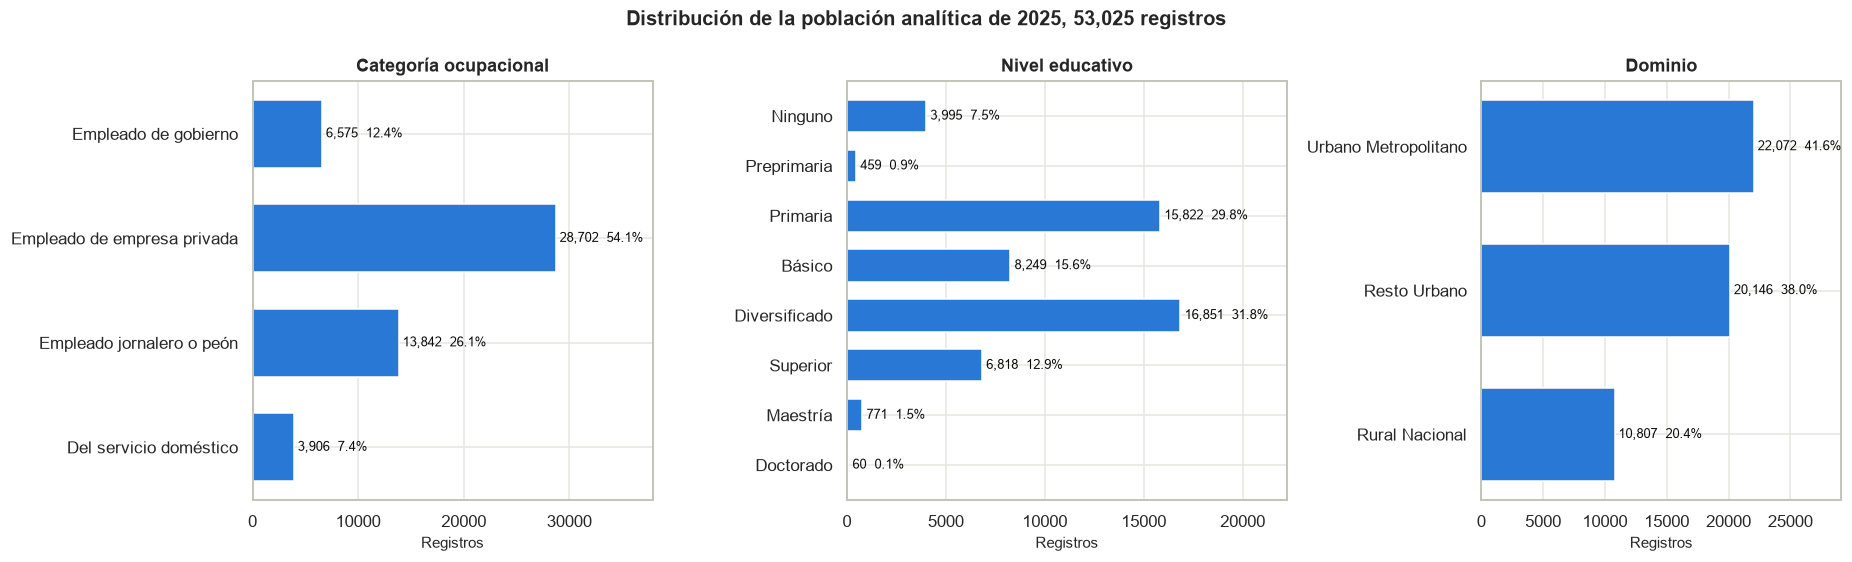

In [33]:
TOTAL_2025 = analitica_2025.count()


def distribucion(columna, orden):
    tabla = analitica_2025.groupBy(columna).count().toPandas().set_index(columna).reindex(orden).fillna(0)
    tabla["porcentaje"] = 100 * tabla["count"] / TOTAL_2025
    return tabla.rename(columns={"count": "registros"})


dist_ocupacional = distribucion("categoria_ocupacional_etiqueta", ORDEN_OCUPACIONAL)
dist_educativo = distribucion("nivel_educativo_etiqueta", ORDEN_EDUCATIVO)
dist_dominio = distribucion("dominio_etiqueta", ORDEN_DOMINIO)

figura, ejes = plt.subplots(1, 3, figsize=(17, 5.2), gridspec_kw={"width_ratios": [1, 1.1, 0.9]})
for eje, tabla, titulo in [
    (ejes[0], dist_ocupacional, "Categoría ocupacional"),
    (ejes[1], dist_educativo, "Nivel educativo"),
    (ejes[2], dist_dominio, "Dominio"),
]:
    eje.barh(tabla.index, tabla["registros"], color=COLOR_PRINCIPAL, height=0.65)
    eje.invert_yaxis()
    eje.set_title(titulo)
    eje.set_xlabel("Registros")
    limite = tabla["registros"].max() * 1.32
    eje.set_xlim(0, limite)
    for posicion, (valor, pct) in enumerate(zip(tabla["registros"], tabla["porcentaje"])):
        eje.text(valor + limite * 0.01, posicion, f"{int(valor):,}  {pct:.1f}%", va="center", fontsize=8.5, color="#0b0b0b")
figura.suptitle(f"Distribución de la población analítica de 2025, {TOTAL_2025:,} registros", fontsize=13, fontweight="bold")
plt.tight_layout()
guardar_figura("Distribución de los registros de 2025 por categoría ocupacional, nivel educativo y dominio")
plt.show()

### 2.3 – Forma de la distribución del salario

Asimetría, curtosis y distancia entre media y mediana sobre el conjunto completo. Los histogramas usan conteos de Spark; la escala logarítmica es solo visual y el objetivo del modelado sigue en quetzales.

In [34]:
forma = analitica_2025.agg(
    F.mean("salario_mensual").alias("media"),
    F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
    F.expr("percentile(salario_mensual, 0.99)").alias("p99"),
    F.skewness("salario_mensual").alias("asimetria"),
    F.kurtosis("salario_mensual").alias("curtosis_exceso"),
).first().asDict()
forma["media_menos_mediana"] = forma["media"] - forma["mediana"]
forma["razon_media_mediana"] = forma["media"] / forma["mediana"]
forma["registros_sobre_media_pct"] = 100 * analitica_2025.filter(F.col("salario_mensual") > forma["media"]).count() / TOTAL_2025
mostrar(pd.DataFrame({"medida": list(forma), "valor": list(forma.values())}), decimales={"valor": 3})

,medida,valor
0,media,"3,421.684"
1,mediana,"3,000.000"
2,p99,"15,000.000"
3,asimetria,5.997
4,curtosis_exceso,103.519
5,media_menos_mediana,421.684
6,razon_media_mediana,1.141
7,registros_sobre_media_pct,43.723


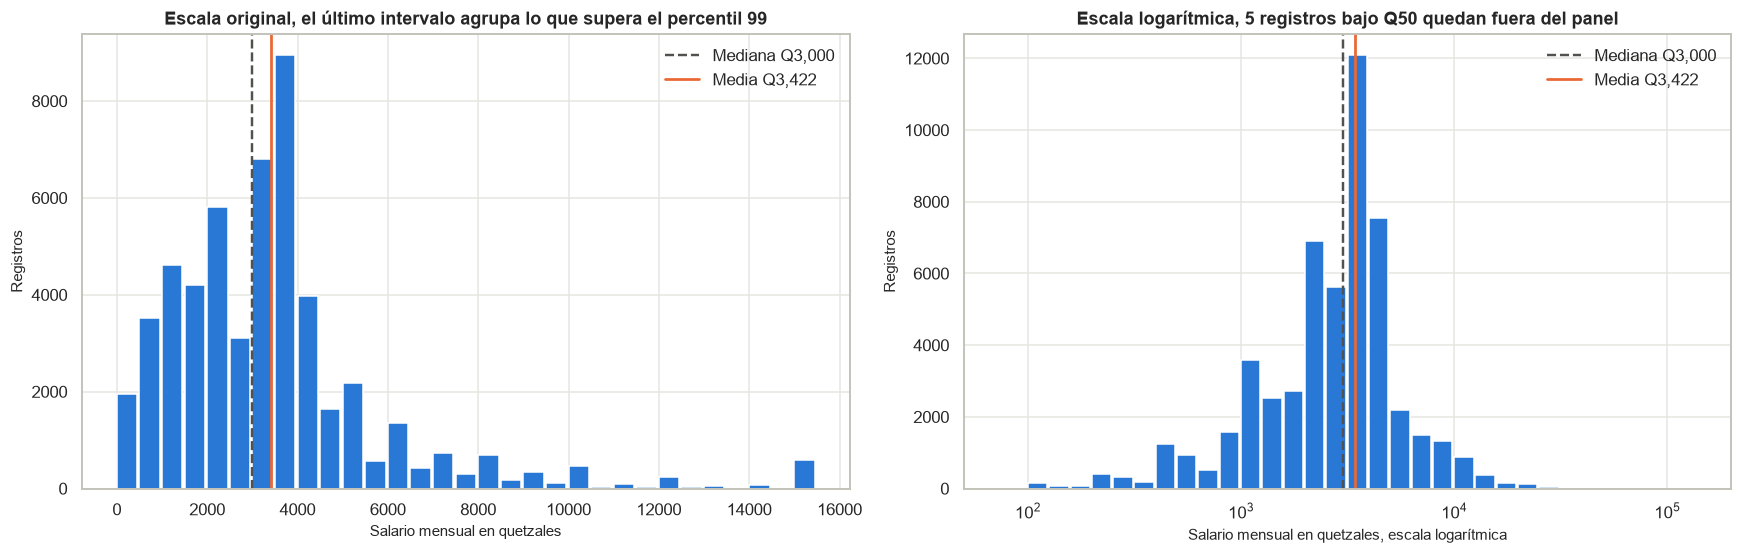

In [35]:
ANCHO = 500
tope = math.ceil(forma["p99"] / ANCHO) * ANCHO

hist_original = (
    analitica_2025.withColumn("intervalo", F.least(F.floor(F.col("salario_mensual") / ANCHO) * ANCHO, F.lit(tope)))
    .groupBy("intervalo").count().orderBy("intervalo").toPandas()
)
hist_log = (
    analitica_2025.withColumn("intervalo", F.floor(F.log10("salario_mensual") / 0.1) * 0.1)
    .groupBy("intervalo").count().orderBy("intervalo").toPandas()
)
LIMITE_INFERIOR = 50
fuera_del_panel = analitica_2025.filter(F.col("salario_mensual") < LIMITE_INFERIOR).count()

figura, ejes = plt.subplots(1, 2, figsize=(16, 5.2))
ejes[0].bar(hist_original["intervalo"], hist_original["count"], width=ANCHO * 0.9, align="edge", color=COLOR_PRINCIPAL)
ejes[0].set_title("Escala original, el último intervalo agrupa lo que supera el percentil 99")
ejes[0].set_xlabel("Salario mensual en quetzales")

ejes[1].bar(10 ** hist_log["intervalo"], hist_log["count"], align="edge", color=COLOR_PRINCIPAL,
            width=(10 ** (hist_log["intervalo"] + 0.1) - 10 ** hist_log["intervalo"]) * 0.9)
ejes[1].set_xscale("log")
ejes[1].set_xlim(LIMITE_INFERIOR, 2e5)
ejes[1].set_title(f"Escala logarítmica, {fuera_del_panel} registros bajo Q{LIMITE_INFERIOR} quedan fuera del panel")
ejes[1].set_xlabel("Salario mensual en quetzales, escala logarítmica")

for eje in ejes:
    eje.axvline(forma["mediana"], color=COLOR_REFERENCIA, linestyle="--", linewidth=1.6, label=f"Mediana Q{forma['mediana']:,.0f}")
    eje.axvline(forma["media"], color=COLOR_CONTRASTE, linewidth=1.8, label=f"Media Q{forma['media']:,.0f}")
    eje.set_ylabel("Registros")
    eje.legend(frameon=False)
plt.tight_layout()
guardar_figura("Distribución del salario mensual de 2025 en escala original y logarítmica")
plt.show()

### 2.4 – Salario por nivel educativo, categoría ocupacional y dominio

Mediana y rango intercuartílico por grupo sobre todos los registros, junto con el número de observaciones.

In [36]:
def salario_por_grupo(sdf, columna, orden):
    tabla = (
        sdf.groupBy(columna)
        .agg(F.count(F.lit(1)).alias("n"),
             F.expr("percentile(salario_mensual, array(0.25, 0.5, 0.75))").alias("p"),
             F.mean("salario_mensual").alias("media"))
        .toPandas().set_index(columna).reindex(orden)
    )
    tabla[["p25", "mediana", "p75"]] = pd.DataFrame(tabla.pop("p").tolist(), index=tabla.index)
    return tabla[["n", "p25", "mediana", "p75", "media"]]


salario_educativo = salario_por_grupo(analitica_2025, "nivel_educativo_etiqueta", ORDEN_EDUCATIVO)
salario_ocupacional = salario_por_grupo(analitica_2025, "categoria_ocupacional_etiqueta", ORDEN_OCUPACIONAL)
salario_dominio = salario_por_grupo(analitica_2025, "dominio_etiqueta", ORDEN_DOMINIO)
for tabla in [salario_educativo, salario_ocupacional, salario_dominio]:
    mostrar(tabla.reset_index(), decimales={c: 0 for c in ["n", "p25", "mediana", "p75", "media"]})

,nivel_educativo_etiqueta,n,p25,mediana,p75,media
0,Ninguno,"3,995",800,"1,500","2,400","1,767"
1,Preprimaria,459,"1,200","2,160","3,000","2,242"
2,Primaria,"15,822","1,200","2,200","3,200","2,308"
3,Básico,"8,249","1,600","2,800","3,600","2,730"
4,Diversificado,"16,851","2,800","3,600","4,250","3,796"
5,Superior,"6,818","3,600","5,000","7,500","5,965"
6,Maestría,771,"6,000","10,000","15,000","11,409"
7,Doctorado,60,"6,000","12,000","21,000","14,452"


,categoria_ocupacional_etiqueta,n,p25,mediana,p75,media
0,Empleado de gobierno,"6,575","3,750","5,000","7,380","5,972"
1,Empleado de empresa privada,"28,702","2,800","3,568","4,000","3,875"
2,Empleado jornalero o peón,"13,842","1,000","1,800","2,490","1,879"
3,Del servicio doméstico,"3,906",600,"1,000","1,600","1,266"


,dominio_etiqueta,n,p25,mediana,p75,media
0,Urbano Metropolitano,"22,072","2,800","3,700","4,500","4,191"
1,Resto Urbano,"20,146","1,600","2,880","3,800","3,131"
2,Rural Nacional,"10,807","1,200","2,000","3,200","2,392"


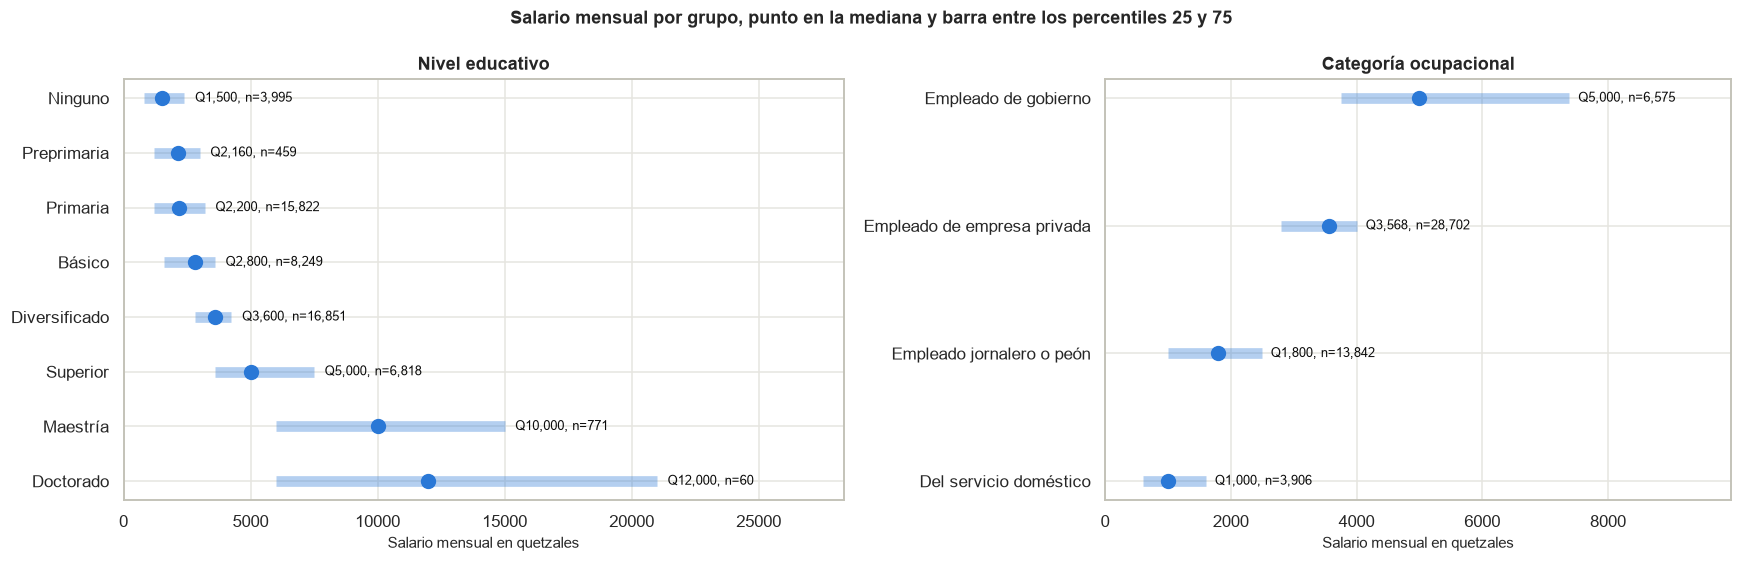

In [37]:
figura, ejes = plt.subplots(1, 2, figsize=(16, 5.2), gridspec_kw={"width_ratios": [1.15, 1]})
for eje, tabla, titulo in [(ejes[0], salario_educativo, "Nivel educativo"), (ejes[1], salario_ocupacional, "Categoría ocupacional")]:
    posiciones = np.arange(len(tabla))
    eje.hlines(posiciones, tabla["p25"], tabla["p75"], color=COLOR_PRINCIPAL, alpha=0.35, linewidth=7)
    eje.plot(tabla["mediana"], posiciones, "o", color=COLOR_PRINCIPAL, markersize=9)
    desplazamiento = tabla["p75"].max() * 0.02
    for y, (mediana, p75, n) in enumerate(zip(tabla["mediana"], tabla["p75"], tabla["n"])):
        eje.text(p75 + desplazamiento, y, f"Q{mediana:,.0f}, n={int(n):,}", va="center", fontsize=8.5, color="#0b0b0b")
    eje.set_yticks(posiciones, tabla.index)
    eje.invert_yaxis()
    eje.set_xlim(0, tabla["p75"].max() * 1.35)
    eje.set_title(titulo)
    eje.set_xlabel("Salario mensual en quetzales")
figura.suptitle("Salario mensual por grupo, punto en la mediana y barra entre los percentiles 25 y 75", fontsize=12, fontweight="bold")
plt.tight_layout()
guardar_figura("Salario mediano y rango intercuartílico por nivel educativo y por categoría ocupacional")
plt.show()

### 2.5 – Tamaño de la muestra y salario por trimestre

,periodo_archivo,n,mediana,media,originales,retencion_pct
0,2025T1,"13,419","3,000","3,315.6","51,588",26.01
1,2025T2,"13,492","3,000","3,364.6","51,167",26.37
2,2025T3,"13,450","3,200","3,469.1","51,583",26.07
3,2025T4,"12,664","3,200","3,544.6","49,338",25.67
4,2026T1,"13,258","3,200","3,565.8","49,843",26.60


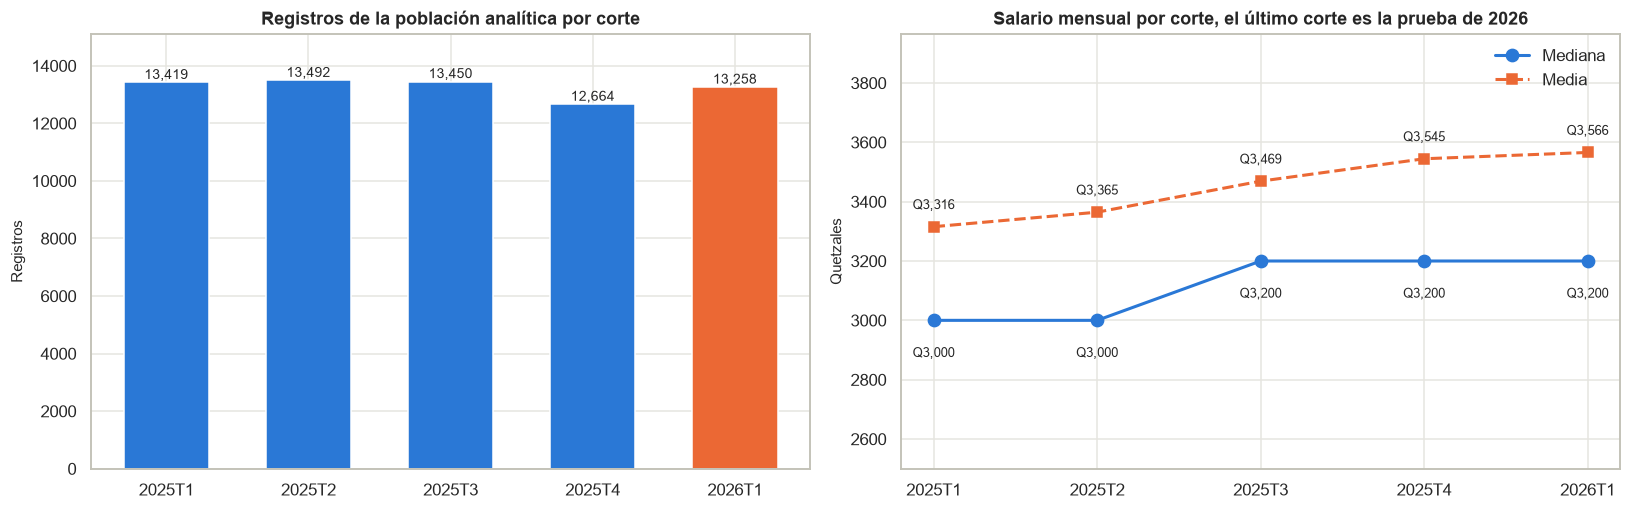

In [38]:
evolucion = (
    analitica_2025.unionByName(analitica_2026)
    .groupBy("periodo_archivo")
    .agg(F.count(F.lit(1)).alias("n"),
         F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
         F.mean("salario_mensual").alias("media"))
    .orderBy("periodo_archivo").toPandas().set_index("periodo_archivo")
)
evolucion["originales"] = por_archivo.loc[evolucion.index, "antes_de_filtros"].astype("int64")
evolucion["retencion_pct"] = 100 * evolucion["n"] / evolucion["originales"]
mostrar(evolucion.reset_index(), decimales={"mediana": 0, "media": 1, "retencion_pct": 2})

figura, ejes = plt.subplots(1, 2, figsize=(15, 4.8))
colores = [COLOR_PRINCIPAL] * 4 + [COLOR_CONTRASTE]
ejes[0].bar(evolucion.index, evolucion["n"], color=colores, width=0.6)
for x, valor in enumerate(evolucion["n"]):
    ejes[0].text(x, valor + 120, f"{valor:,}", ha="center", fontsize=9)
ejes[0].set_ylim(0, evolucion["n"].max() * 1.12)
ejes[0].set_title("Registros de la población analítica por corte")
ejes[0].set_ylabel("Registros")

ejes[1].plot(evolucion.index, evolucion["mediana"], "o-", color=COLOR_PRINCIPAL, linewidth=2, markersize=8, label="Mediana")
ejes[1].plot(evolucion.index, evolucion["media"], "s--", color=COLOR_CONTRASTE, linewidth=2, markersize=7, label="Media")
for x, (mediana, media) in enumerate(zip(evolucion["mediana"], evolucion["media"])):
    ejes[1].text(x, mediana - 90, f"Q{mediana:,.0f}", ha="center", va="top", fontsize=8.5)
    ejes[1].text(x, media + 50, f"Q{media:,.0f}", ha="center", va="bottom", fontsize=8.5)
ejes[1].set_ylim(evolucion["mediana"].min() - 500, evolucion["media"].max() + 400)
ejes[1].set_title("Salario mensual por corte, el último corte es la prueba de 2026")
ejes[1].set_ylabel("Quetzales")
ejes[1].legend(frameon=False)
plt.tight_layout()
guardar_figura("Tamaño de la población analítica y salario mediano y medio por corte")
plt.show()

### 2.6 – Respuestas del Ejercicio 2

**¿Cómo se distribuyen los registros entre categorías ocupacionales, niveles educativos y dominios?**

El empleo privado reúne el 54.1% de los registros, seguido por jornaleros con 26.1%, gobierno con 12.4% y servicio doméstico con 7.4%. En educación predominan diversificado, 31.8%, y primaria, 29.8%; el 7.5% no tiene ningún nivel, y maestría y doctorado apenas suman 771 y 60 registros. Cuatro de cada cinco registros son urbanos: 41.6% metropolitano, 38.0% resto urbano y 20.4% rural.

**¿El salario presenta una distribución simétrica o asimétrica?**

Fuertemente asimétrica a la derecha, con asimetría de 6.0 y curtosis en exceso de 103.5. La mayoría de los salarios está entre Q1,000 y Q5,000, el percentil 95 es Q8,000 y el 99 es Q15,000, pero el máximo llega a Q99,000. En escala logarítmica la forma se vuelve casi simétrica. Hay además agrupamiento en montos redondos como Q3,000 y Q4,000. El máximo corresponde a una misma persona reportada con Q99,000 en tres cortes consecutivos, por lo que parece una respuesta consistente y se conserva.

**¿Qué diferencia existe entre su media y su mediana?**

La media es Q3,421.68 y la mediana Q3,000, una diferencia de Q421.68, el 14.1%, y solo el 43.7% de los registros supera la media. Los salarios altos elevan el promedio sin mover la mediana, que por eso representa mejor el salario típico. Para el modelado implica que el RMSE dará mucho peso a los casos extremos.

**¿Cómo varía el salario mediano entre niveles educativos y categorías ocupacionales?**

Crece con cada nivel educativo: Q1,500 sin educación, Q2,200 con primaria, Q3,600 con diversificado, Q5,000 con superior, Q10,000 con maestría y Q12,000 con doctorado, aunque este último se basa en solo 60 registros. Por categoría va de Q1,000 en servicio doméstico y Q1,800 en jornaleros a Q3,568 en empresa privada y Q5,000 en gobierno. Por dominio baja de Q3,700 en el área metropolitana a Q2,000 en el área rural.

**¿Cómo cambian el tamaño de la muestra analítica y el salario mediano entre trimestres?**

El tamaño es estable, entre 12,664 y 13,492 registros por corte, con retención cercana al 26%. La mediana sube de Q3,000 en los dos primeros trimestres de 2025 a Q3,200 desde el tercero y se mantiene en 2026, mientras la media crece de forma continua de Q3,315.6 a Q3,565.8. Los modelos se entrenarán con 2025 y se probarán en un período con salarios algo mayores.

## Ejercicio 3 – Correlación de Pearson entre salario, edad, antigüedad y horas

Matriz de Pearson con VectorAssembler y Correlation.corr sobre todos los registros elegibles de 2025. La correlación de Spearman se agrega como complemento, porque es menos sensible a la asimetría del salario.

In [39]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

VARIABLES_CORRELACION = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
ETIQUETAS_CORRELACION = ["Salario", "Edad", "Antigüedad", "Horas"]

vector_correlacion = VectorAssembler(inputCols=VARIABLES_CORRELACION, outputCol="variables").transform(
    analitica_2025.select(*VARIABLES_CORRELACION)
)
matrices = {
    metodo: pd.DataFrame(Correlation.corr(vector_correlacion, "variables", metodo).first()[0].toArray(),
                         index=ETIQUETAS_CORRELACION, columns=ETIQUETAS_CORRELACION)
    for metodo in ["pearson", "spearman"]
}
matriz_pearson = matrices["pearson"]
print(f"Registros utilizados: {vector_correlacion.count():,}")
print("Correlacion de Pearson")
mostrar(matriz_pearson.rename_axis("variable").reset_index(), decimales={c: 4 for c in ETIQUETAS_CORRELACION})
print("Correlacion de Spearman, complemento")
mostrar(matrices["spearman"].rename_axis("variable").reset_index(), decimales={c: 4 for c in ETIQUETAS_CORRELACION})

Registros utilizados: 53,025
Correlacion de Pearson


,variable,Salario,Edad,Antigüedad,Horas
0,Salario,1.0000,0.1472,0.1796,0.0757
1,Edad,0.1472,1.0000,0.4867,-0.1054
2,Antigüedad,0.1796,0.4867,1.0000,-0.0623
3,Horas,0.0757,-0.1054,-0.0623,1.0000


Correlacion de Spearman, complemento


,variable,Salario,Edad,Antigüedad,Horas
0,Salario,1.0000,0.1526,0.2610,0.1431
1,Edad,0.1526,1.0000,0.4189,-0.1200
2,Antigüedad,0.2610,0.4189,1.0000,-0.0482
3,Horas,0.1431,-0.1200,-0.0482,1.0000


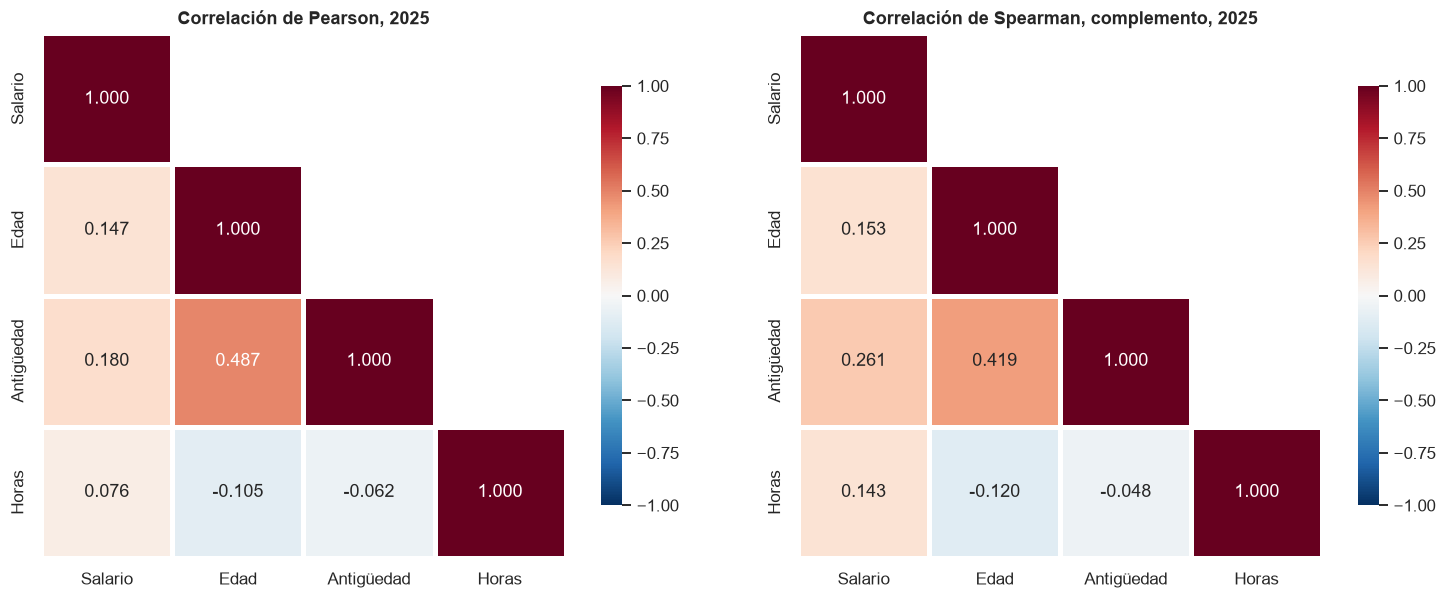

In [40]:
figura, ejes = plt.subplots(1, 2, figsize=(14, 5.4))
for eje, (metodo, titulo) in zip(ejes, [("pearson", "Pearson"), ("spearman", "Spearman, complemento")]):
    matriz = matrices[metodo]
    sns.heatmap(matriz, mask=np.triu(np.ones_like(matriz, dtype=bool), k=1), annot=True, fmt=".3f", cmap="RdBu_r",
                center=0, vmin=-1, vmax=1, square=True, linewidths=2, linecolor="white", cbar_kws={"shrink": 0.8}, ax=eje)
    eje.grid(False)
    eje.set_title(f"Correlación de {titulo}, 2025")
plt.tight_layout()
guardar_figura("Mapa de calor de la correlación de Pearson y de Spearman entre salario, edad, antigüedad y horas")
plt.show()

Registros de la muestra de visualizacion: 5,000


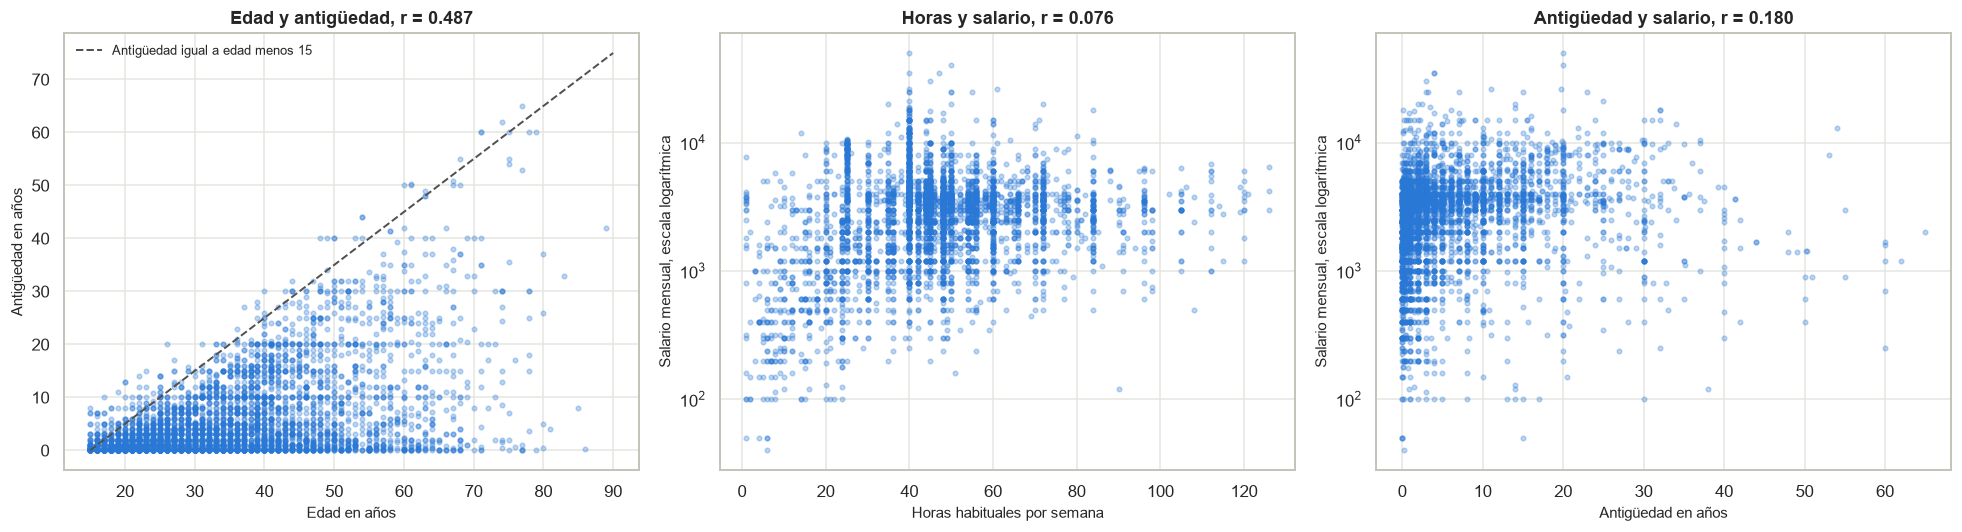

In [41]:
# muestra acotada unicamente para visualizar las nubes de puntos
muestra_relaciones = (
    analitica_2025.select(*VARIABLES_CORRELACION)
    .sample(withReplacement=False, fraction=0.12, seed=SEMILLA).limit(5000).toPandas()
)
print(f"Registros de la muestra de visualizacion: {len(muestra_relaciones):,}")

figura, ejes = plt.subplots(1, 3, figsize=(18, 5))
ejes[0].scatter(muestra_relaciones["edad"], muestra_relaciones["antiguedad"], s=9, alpha=0.3, color=COLOR_PRINCIPAL)
ejes[0].plot([15, 90], [0, 75], color=COLOR_REFERENCIA, linestyle="--", linewidth=1.3, label="Antigüedad igual a edad menos 15")
ejes[0].set_title(f"Edad y antigüedad, r = {matriz_pearson.loc['Edad', 'Antigüedad']:.3f}")
ejes[0].set_xlabel("Edad en años")
ejes[0].set_ylabel("Antigüedad en años")
ejes[0].legend(frameon=False, fontsize=8.5)

for eje, variable, nombre, etiqueta in [(ejes[1], "horas_semanales", "Horas", "Horas habituales por semana"),
                                        (ejes[2], "antiguedad", "Antigüedad", "Antigüedad en años")]:
    eje.scatter(muestra_relaciones[variable], muestra_relaciones["salario_mensual"], s=9, alpha=0.3, color=COLOR_PRINCIPAL)
    eje.set_yscale("log")
    eje.set_title(f"{nombre} y salario, r = {matriz_pearson.loc[nombre, 'Salario']:.3f}")
    eje.set_xlabel(etiqueta)
    eje.set_ylabel("Salario mensual, escala logarítmica")
plt.tight_layout()
guardar_figura("Relación entre edad y antigüedad y entre horas, antigüedad y salario, muestra de 5,000 registros")
plt.show()

### 3.1 – Respuestas del Ejercicio 3

**¿Qué variables presentan mayor asociación lineal con el salario?**

Ninguna tiene una asociación fuerte. La antigüedad es la más asociada, con r igual a 0.180, seguida por la edad con 0.147 y las horas con 0.076; por sí sola, ninguna explica más del 3.3% de la variación del salario. Spearman da valores algo mayores, 0.261 para antigüedad y 0.143 para horas, lo que indica que la asimetría del salario debilita a Pearson, pero incluso en rangos las relaciones siguen siendo débiles. Esto anticipa que el nivel educativo y la categoría ocupacional, que en el Ejercicio 2 separaban claramente el salario, serán los predictores más informativos.

**¿Existe relación entre edad y antigüedad?**

Sí, es la asociación más fuerte de la matriz, con r igual a 0.487 y Spearman de 0.419, ya que la antigüedad solo se acumula con los años. No es más fuerte porque la relación es triangular: la antigüedad no puede superar la edad menos los años previos al empleo, pero una persona mayor puede tener cualquier antigüedad por debajo de ese límite si cambió de trabajo. Las horas casi no se relacionan con edad ni antigüedad, por lo que las tres variables aportan información distinta.

## Ejercicio 4 – Segmentación de perfiles de asalariados mediante KMeans

Perfiles según edad, antigüedad y jornada. Se comparan tres espacios, sin salario, con salario y con su logaritmo, estandarizados con StandardScaler y evaluados con K de 2 a 5 mediante inercia, silueta y tamaño del menor clúster.

### 4.1 – Espacios de agrupamiento y estandarización

KMeans usa distancia euclidiana, así que cada espacio se estandariza para que ninguna variable domine por su escala. Los centroides quedan en desviaciones estándar respecto del promedio.

In [42]:
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import StandardScaler

ESPACIOS = {
    "Sin salario": ["edad", "antiguedad", "horas_semanales"],
    "Con salario": ["edad", "antiguedad", "horas_semanales", "salario_mensual"],
    "Con logaritmo del salario": ["edad", "antiguedad", "horas_semanales", "log_salario"],
}
COLUMNA_ESPACIO = {nombre: f"z_{i}" for i, nombre in enumerate(ESPACIOS)}

base_segmentacion = analitica_2025.withColumn("log_salario", F.log("salario_mensual")).select(
    "periodo_archivo", "NUM_HOGAR", "NUM_PERSONA", "edad", "antiguedad", "horas_semanales", "salario_mensual", "log_salario",
    "nivel_educativo_etiqueta", "categoria_ocupacional_etiqueta", "dominio_etiqueta",
)
for nombre, variables in ESPACIOS.items():
    columna = COLUMNA_ESPACIO[nombre]
    escalado = Pipeline(stages=[
        VectorAssembler(inputCols=variables, outputCol=f"v{columna}"),
        StandardScaler(inputCol=f"v{columna}", outputCol=columna, withMean=True, withStd=True),
    ]).fit(base_segmentacion)
    base_segmentacion = escalado.transform(base_segmentacion).drop(f"v{columna}")

base_segmentacion = base_segmentacion.persist()
print(f"Registros utilizados: {base_segmentacion.count():,}")
mostrar(pd.DataFrame([{"espacio": n, "variables": ", ".join(v), "columna": COLUMNA_ESPACIO[n]} for n, v in ESPACIOS.items()]))

Registros utilizados: 53,025


,espacio,variables,columna
0,Sin salario,"edad, antiguedad, horas_semanales",z_0
1,Con salario,"edad, antiguedad, horas_semanales, salario_men...",z_1
2,Con logaritmo del salario,"edad, antiguedad, horas_semanales, log_salario",z_2


### 4.2 – Evaluación de los espacios y de los valores de K

Para cada combinación se registran inercia, reducción relativa de inercia, silueta sobre todos los registros, tamaño del menor clúster y la mayor distancia de un centroide al promedio en cada variable.

In [43]:
VALORES_K = [2, 3, 4, 5]
resultados_k, modelos_k = [], {}

for nombre, variables in ESPACIOS.items():
    columna = COLUMNA_ESPACIO[nombre]
    evaluador = ClusteringEvaluator(featuresCol=columna, predictionCol="cluster", metricName="silhouette",
                                    distanceMeasure="squaredEuclidean")
    for k in VALORES_K:
        modelo = KMeans(featuresCol=columna, predictionCol="cluster", k=k, seed=SEMILLA, maxIter=100).fit(base_segmentacion)
        modelos_k[(nombre, k)] = modelo
        tamanios = modelo.summary.clusterSizes
        fila = {"espacio": nombre, "k": k, "inercia": modelo.summary.trainingCost,
                "silueta": evaluador.evaluate(modelo.transform(base_segmentacion)),
                "cluster_menor_pct": 100 * min(tamanios) / sum(tamanios)}
        fila.update({f"max_z_{v}": z for v, z in zip(variables, np.abs(np.array(modelo.clusterCenters())).max(axis=0))})
        resultados_k.append(fila)

tabla_k = pd.DataFrame(resultados_k)
tabla_k["reduccion_inercia_pct"] = -100 * tabla_k.groupby("espacio")["inercia"].pct_change()
tabla_k["cumple_tamanio"] = tabla_k["cluster_menor_pct"] >= 5
columnas_z = [c for c in tabla_k.columns if c.startswith("max_z_")]
mostrar(tabla_k[["espacio", "k", "inercia", "reduccion_inercia_pct", "silueta", "cluster_menor_pct", "cumple_tamanio"] + columnas_z],
        decimales={"inercia": 0, "reduccion_inercia_pct": 2, "silueta": 4, "cluster_menor_pct": 2, **{c: 2 for c in columnas_z}},
        vacio="No aplica")

,espacio,k,inercia,reduccion_inercia_pct,silueta,cluster_menor_pct,cumple_tamanio,max_z_edad,max_z_antiguedad,max_z_horas_semanales,max_z_salario_mensual,max_z_log_salario
0,Sin salario,2,"106,717",No aplica,0.5545,27.54,Sí,1.19,1.05,0.27,No aplica,No aplica
1,Sin salario,3,"83,608",21.65,0.4716,19.07,Sí,1.26,1.28,1.44,No aplica,No aplica
2,Sin salario,4,"64,438",22.93,0.4760,12.95,Sí,1.09,2.13,1.53,No aplica,No aplica
3,Sin salario,5,"54,990",14.66,0.4839,11.65,Sí,1.11,2.17,1.85,No aplica,No aplica
4,Con salario,2,"157,346",No aplica,0.5146,27.03,Sí,1.15,1.09,0.23,0.48,No aplica
5,Con salario,3,"133,003",15.47,0.3371,16.76,Sí,1.06,1.72,0.73,0.87,No aplica
6,Con salario,4,"113,688",14.52,0.3753,4.40,No,1.14,1.98,0.71,3.16,No aplica
7,Con salario,5,"94,476",16.90,0.4137,3.98,No,1.09,2.15,1.52,3.32,No aplica
8,Con logaritmo del salario,2,"159,174",No aplica,0.4702,28.27,Sí,1.16,1.04,0.21,No aplica,0.24
9,Con logaritmo del salario,3,"125,145",21.38,0.4753,17.60,Sí,1.17,1.49,1.08,No aplica,1.45


**¿Vale la pena incluir el salario en la segmentación?**

No. Con el salario en quetzales la silueta cae a 0.337 en K igual a 3 y, en K igual a 4 y 5, aparece un clúster de menos del 5% de los registros cuyo centroide se aleja más de 3 desviaciones estándar en salario: el algoritmo dedica un grupo a aislar salarios extremos en lugar de describir un perfil. El logaritmo del salario corrige eso y alcanza 0.475 en K igual a 3, pero baja a 0.372 y 0.387 en K igual a 4 y 5, por debajo del espacio sin salario. Además, si el salario forma los grupos, compararlo después entre perfiles se vuelve circular. Por eso se usa como descriptor y no como variable de agrupamiento.

### 4.3 – Criterio de selección y modelo elegido

Dentro del espacio sin salario, K debe cumplir tres condiciones verificadas en código: ningún clúster con menos del 5% de los registros, cada variable debe separar al menos un grupo por una desviación estándar o más, y entre los admisibles se elige la mayor silueta, contrastada con el codo.

In [44]:
ESPACIO_ELEGIDO = "Sin salario"
UMBRAL_DIFERENCIACION = 1.0

curva = tabla_k[tabla_k["espacio"] == ESPACIO_ELEGIDO].copy()
curva["diferencia_todas"] = (curva[[f"max_z_{v}" for v in ESPACIOS[ESPACIO_ELEGIDO]]] >= UMBRAL_DIFERENCIACION).all(axis=1)
curva["admisible"] = curva["cumple_tamanio"] & curva["diferencia_todas"]
mostrar(curva[["k", "silueta", "reduccion_inercia_pct", "cluster_menor_pct", "cumple_tamanio", "diferencia_todas", "admisible"]],
        decimales={"silueta": 4, "reduccion_inercia_pct": 2, "cluster_menor_pct": 2}, vacio="No aplica")

K_ELEGIDO = int(curva[curva["admisible"]].sort_values("silueta", ascending=False).iloc[0]["k"])
modelo_elegido = modelos_k[(ESPACIO_ELEGIDO, K_ELEGIDO)]
fila_elegida = curva.set_index("k").loc[K_ELEGIDO]
print(f"Espacio elegido: {ESPACIO_ELEGIDO}, K = {K_ELEGIDO}, silueta = {fila_elegida['silueta']:.4f}, "
      f"cluster menor = {fila_elegida['cluster_menor_pct']:.2f}%")

,k,silueta,reduccion_inercia_pct,cluster_menor_pct,cumple_tamanio,diferencia_todas,admisible
0,2,0.5545,No aplica,27.54,Sí,No,No
1,3,0.4716,21.65,19.07,Sí,Sí,Sí
2,4,0.4760,22.93,12.95,Sí,Sí,Sí
3,5,0.4839,14.66,11.65,Sí,Sí,Sí


Espacio elegido: Sin salario, K = 5, silueta = 0.4839, cluster menor = 11.65%


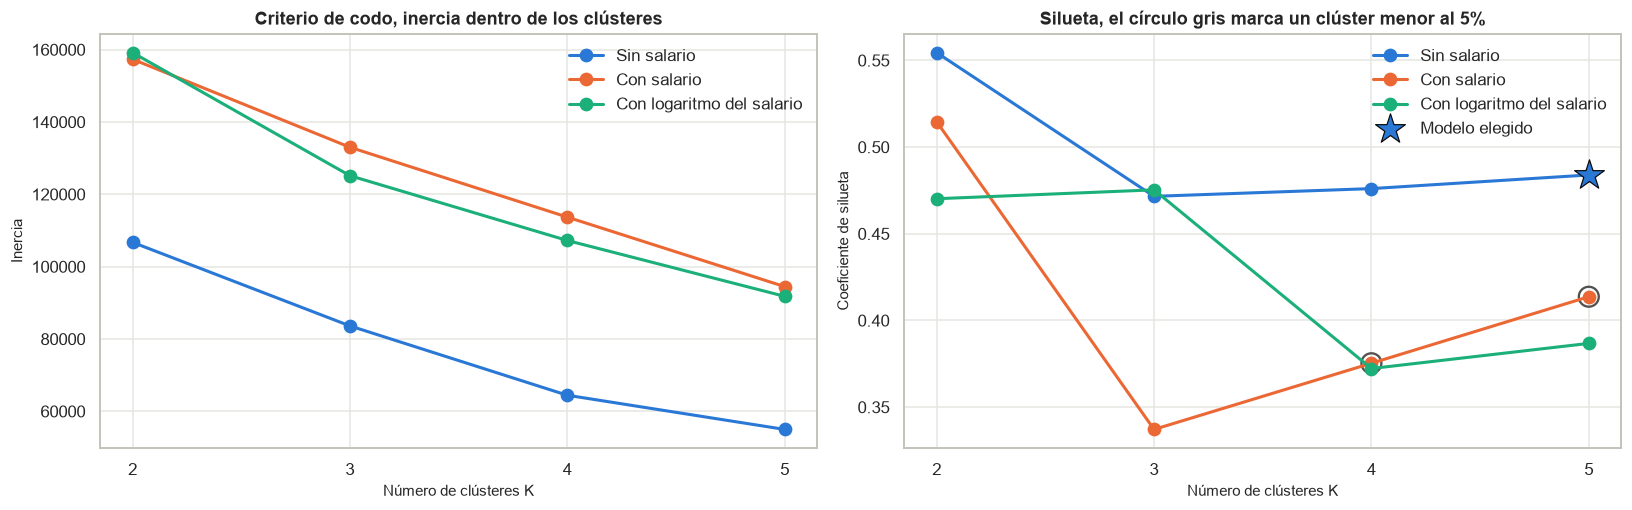

In [45]:
figura, ejes = plt.subplots(1, 2, figsize=(15, 4.8))
for posicion, (nombre, grupo) in enumerate(tabla_k.groupby("espacio", sort=False)):
    color = PALETA_GRUPOS[posicion]
    ejes[0].plot(grupo["k"], grupo["inercia"], "o-", color=color, linewidth=2, markersize=8, label=nombre)
    ejes[1].plot(grupo["k"], grupo["silueta"], "o-", color=color, linewidth=2, markersize=8, label=nombre)
    descartados = grupo[~grupo["cumple_tamanio"]]
    ejes[1].scatter(descartados["k"], descartados["silueta"], s=170, facecolors="none", edgecolors=COLOR_REFERENCIA, linewidths=1.5)
ejes[1].scatter([K_ELEGIDO], [fila_elegida["silueta"]], marker="*", s=420, color=PALETA_GRUPOS[0],
                edgecolors="#0b0b0b", linewidths=0.8, zorder=5, label="Modelo elegido")
ejes[0].set_title("Criterio de codo, inercia dentro de los clústeres")
ejes[0].set_ylabel("Inercia")
ejes[1].set_title("Silueta, el círculo gris marca un clúster menor al 5%")
ejes[1].set_ylabel("Coeficiente de silueta")
for eje in ejes:
    eje.set_xlabel("Número de clústeres K")
    eje.set_xticks(VALORES_K)
    eje.legend(frameon=False)
plt.tight_layout()
guardar_figura("Criterio de codo y coeficiente de silueta por espacio de agrupamiento y valor de K")
plt.show()

K igual a 2 tiene la mayor silueta, 0.555, pero sus centroides apenas se separan 0.27 desviaciones estándar en horas: solo divide jóvenes de mayores, la misma relación vista en el Ejercicio 3, y deja la jornada fuera. Los valores 3, 4 y 5 son admisibles y la silueta crece con K, de 0.472 a 0.476 y a 0.484, de modo que el criterio elige K igual a 5, con un clúster menor del 11.65%. El codo es consistente: cada grupo adicional sigue reduciendo la inercia al menos 14.7%. Una silueta cercana a 0.48 indica estructura moderada, así que los perfiles describen regiones de un continuo más que grupos aislados.

### 4.4 – Perfiles del modelo seleccionado

Cada perfil se describe en unidades originales, con su salario y su composición. Los perfiles se numeran por edad media ascendente. El salario no intervino en el agrupamiento.

In [46]:
asignada = modelo_elegido.transform(base_segmentacion)
orden = asignada.groupBy("cluster").agg(F.mean("edad").alias("e")).toPandas().sort_values("e")["cluster"].tolist()
recodificar = F.create_map(*[x for i, c in enumerate(orden) for x in (F.lit(c), F.lit(i + 1))])
asignada = asignada.withColumn("perfil", F.element_at(recodificar, F.col("cluster"))).persist()

perfiles = (
    asignada.groupBy("perfil")
    .agg(F.count(F.lit(1)).alias("n"),
         F.mean("edad").alias("edad_media"),
         F.mean("antiguedad").alias("antiguedad_media"),
         F.expr("percentile(antiguedad, 0.5)").alias("antiguedad_mediana"),
         F.mean("horas_semanales").alias("horas_medias"),
         F.expr("percentile(horas_semanales, 0.5)").alias("horas_mediana"),
         F.expr("percentile(salario_mensual, 0.5)").alias("salario_mediano"),
         F.mean("salario_mensual").alias("salario_medio"))
    .orderBy("perfil").toPandas().set_index("perfil")
)
perfiles.insert(1, "participacion_pct", 100 * perfiles["n"] / perfiles["n"].sum())
mostrar(perfiles.reset_index(), decimales={c: 1 for c in perfiles.columns if c != "n"})

,perfil,n,participacion_pct,edad_media,antiguedad_media,antiguedad_mediana,horas_medias,horas_mediana,salario_mediano,salario_medio
0,1,"22,716",42.8,26.3,2.6,1.5,47.6,48.0,"3,200.0","3,370.9"
1,2,"6,502",12.3,29.7,2.9,1.2,19.4,21.0,"1,200.0","1,944.2"
2,3,"6,177",11.6,31.1,3.7,2.0,80.8,76.0,"3,000.0","3,266.7"
3,4,"11,006",20.8,50.0,4.2,3.0,43.4,44.0,"3,200.0","3,707.0"
4,5,"6,624",12.5,50.2,22.5,20.0,41.2,40.0,"3,800.0","4,716.5"


In [47]:
def composicion(columna, orden_categorias):
    """Porcentaje de cada categoria dentro de cada perfil."""
    tabla = asignada.groupBy("perfil", columna).count().toPandas().pivot(index="perfil", columns=columna, values="count")
    tabla = tabla.reindex(columns=[c for c in orden_categorias if c in tabla.columns]).fillna(0)
    return 100 * tabla.div(tabla.sum(axis=1), axis=0)


for titulo, columna, orden_categorias in [
    ("Categoria ocupacional", "categoria_ocupacional_etiqueta", ORDEN_OCUPACIONAL),
    ("Nivel educativo", "nivel_educativo_etiqueta", ORDEN_EDUCATIVO),
    ("Dominio", "dominio_etiqueta", ORDEN_DOMINIO),
]:
    tabla = composicion(columna, orden_categorias)
    print(f"{titulo}, porcentaje dentro de cada perfil")
    mostrar(tabla.reset_index(), decimales={c: 1 for c in tabla.columns})

Categoria ocupacional, porcentaje dentro de cada perfil


categoria_ocupacional_etiqueta,perfil,Empleado de gobierno,Empleado de empresa privada,Empleado jornalero o peón,Del servicio doméstico
0,1,6.7,63.8,25.3,4.1
1,2,14.7,28.1,40.0,17.3
2,3,9.5,67.0,17.9,5.6
3,4,12.9,50.7,26.4,10.0
4,5,31.5,40.4,22.2,5.9


Nivel educativo, porcentaje dentro de cada perfil


nivel_educativo_etiqueta,perfil,Ninguno,Preprimaria,Primaria,Básico,Diversificado,Superior,Maestría,Doctorado
0,1,3.3,0.6,25.1,18.0,39.9,12.1,1.1,0.0
1,2,8.5,1.0,32.0,17.1,26.1,14.8,0.7,0.0
2,3,4.9,0.9,34.7,21.2,33.2,4.7,0.4,0.0
3,4,14.0,1.3,36.9,10.9,21.6,12.6,2.6,0.2
4,5,13.1,1.2,27.6,8.2,25.3,21.6,2.5,0.5


Dominio, porcentaje dentro de cada perfil


dominio_etiqueta,perfil,Urbano Metropolitano,Resto Urbano,Rural Nacional
0,1,43.6,36.1,20.2
1,2,28.0,44.0,28.0
2,3,31.9,45.1,23.1
3,4,49.2,33.8,17.0
4,5,44.6,38.9,16.5


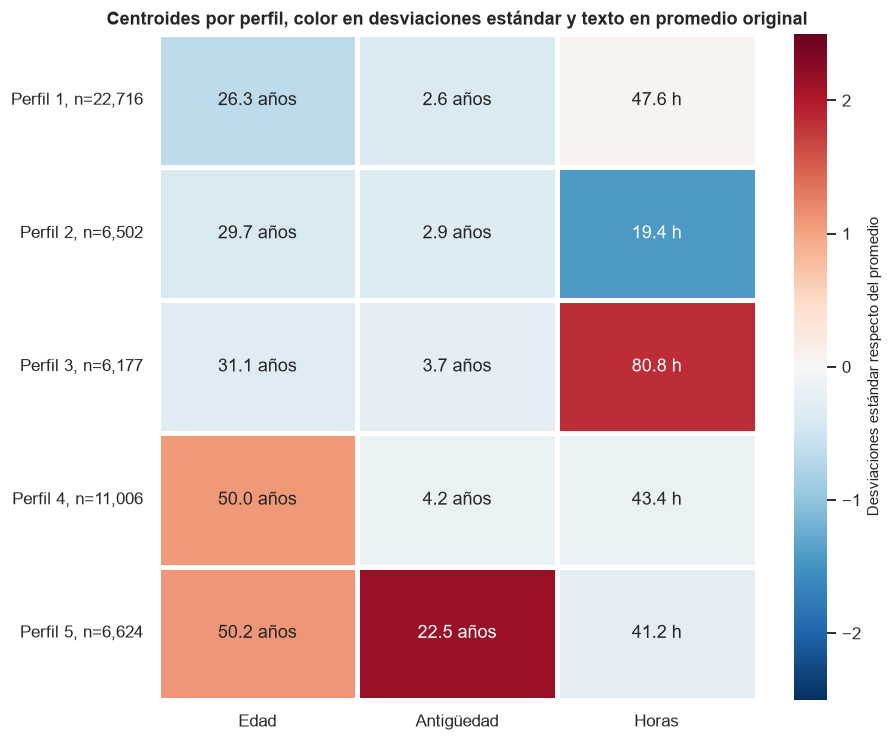

In [48]:
nombres_espacio = ["Edad", "Antigüedad", "Horas"]
centros_z = pd.DataFrame(modelo_elegido.clusterCenters(), columns=nombres_espacio)
centros_z.index = [orden.index(c) + 1 for c in range(K_ELEGIDO)]
centros_z = centros_z.sort_index()
promedios = perfiles[["edad_media", "antiguedad_media", "horas_medias"]].to_numpy()
anotaciones = np.array([[f"{fila[0]:.1f} años", f"{fila[1]:.1f} años", f"{fila[2]:.1f} h"] for fila in promedios])

figura, eje = plt.subplots(figsize=(8.5, 1.1 * K_ELEGIDO + 1.4))
sns.heatmap(centros_z, annot=anotaciones, fmt="", cmap="RdBu_r", center=0, vmin=-2.5, vmax=2.5, linewidths=2,
            linecolor="white", cbar_kws={"label": "Desviaciones estándar respecto del promedio"}, ax=eje)
eje.set_yticklabels([f"Perfil {p}, n={int(n):,}" for p, n in perfiles["n"].items()], rotation=0)
eje.set_xticklabels(nombres_espacio, rotation=0)
eje.set_title("Centroides por perfil, color en desviaciones estándar y texto en promedio original")
plt.tight_layout()
guardar_figura("Centroides estandarizados de los perfiles con sus promedios en unidades originales")
plt.show()

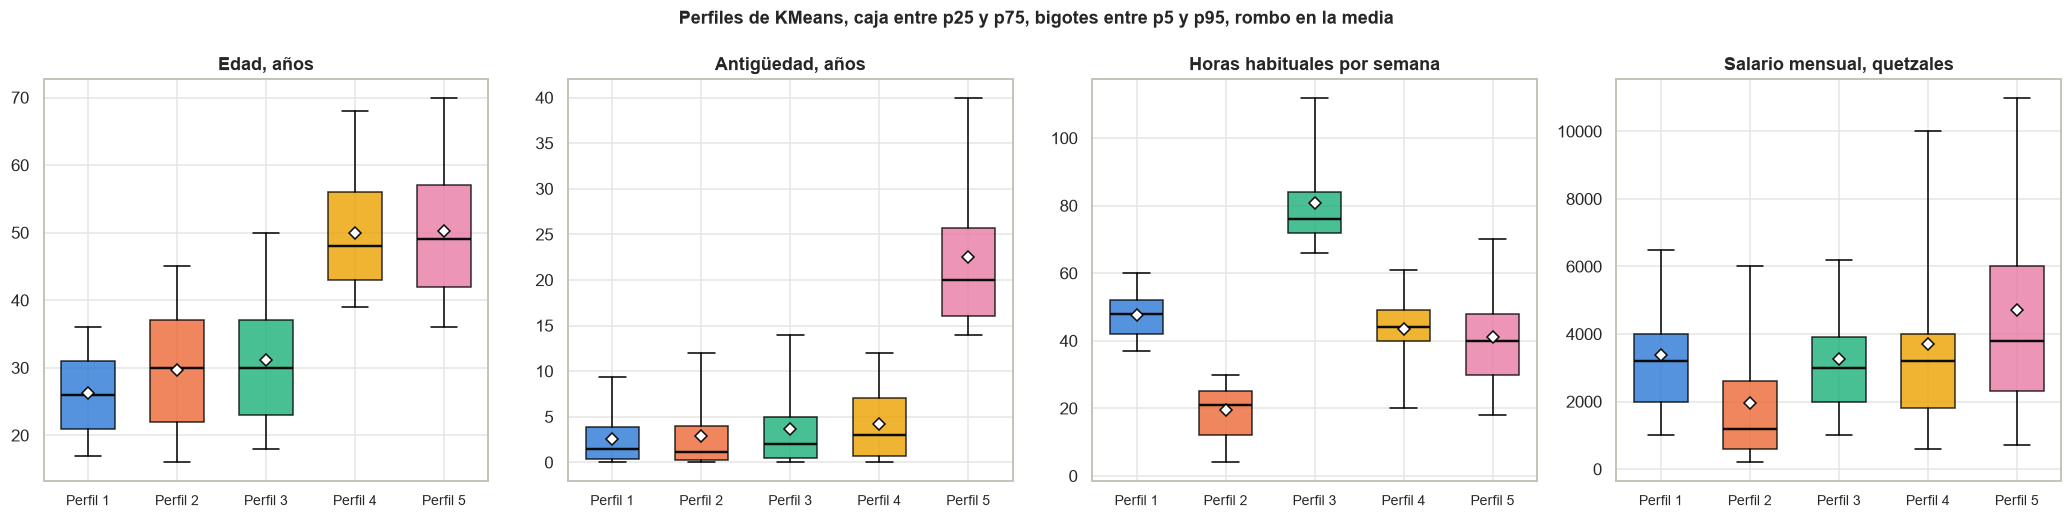

In [49]:
# estadisticos de caja calculados en Spark sobre todos los registros, bigotes en los percentiles 5 y 95
VARIABLES_CAJA = [("edad", "Edad, años"), ("antiguedad", "Antigüedad, años"),
                  ("horas_semanales", "Horas habituales por semana"), ("salario_mensual", "Salario mensual, quetzales")]
cuantiles = (
    asignada.groupBy("perfil")
    .agg(*[F.expr(f"percentile({v}, array(0.05, 0.25, 0.5, 0.75, 0.95))").alias(v) for v, _ in VARIABLES_CAJA],
         *[F.mean(v).alias(f"media_{v}") for v, _ in VARIABLES_CAJA])
    .orderBy("perfil").toPandas().set_index("perfil")
)

figura, ejes = plt.subplots(1, 4, figsize=(19, 4.8))
for eje, (variable, titulo) in zip(ejes, VARIABLES_CAJA):
    cajas = [{"label": f"Perfil {p}", "whislo": q[0], "q1": q[1], "med": q[2], "q3": q[3], "whishi": q[4],
              "mean": cuantiles.loc[p, f"media_{variable}"], "fliers": []} for p, q in cuantiles[variable].items()]
    partes = eje.bxp(cajas, showmeans=True, patch_artist=True, widths=0.6,
                     medianprops={"color": "#0b0b0b", "linewidth": 1.6},
                     meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "#0b0b0b", "markersize": 6})
    for caja, color in zip(partes["boxes"], PALETA_GRUPOS):
        caja.set_facecolor(color)
        caja.set_alpha(0.8)
    eje.set_title(titulo)
    eje.tick_params(axis="x", labelsize=9)
figura.suptitle("Perfiles de KMeans, caja entre p25 y p75, bigotes entre p5 y p95, rombo en la media", fontsize=12, fontweight="bold")
plt.tight_layout()
guardar_figura("Distribución de edad, antigüedad, horas y salario por perfil de KMeans sobre todos los registros")
plt.show()

### 4.5 – Descripción de los perfiles

**Perfil 1, jóvenes con jornada completa.** Es el grupo más grande, con 22,716 registros, el 42.8%. Tienen 26.3 años en promedio, 1.5 años de antigüedad mediana y 48 horas semanales. Predomina el empleo privado, 63.8%, y la educación diversificada, 39.9%. Salario mediano de Q3,200.

**Perfil 2, jornada parcial.** Reúne 6,502 registros, el 12.3%. Tienen 29.7 años y trabajan 21 horas semanales de mediana. Concentran jornaleros, 40.0%, y servicio doméstico, 17.3%, pero también un 14.8% con educación superior, y son el perfil más rural, 28.0%. Su salario mediano es de Q1,200, el más bajo, reflejo directo de la menor jornada.

**Perfil 3, jornada extendida.** Reúne 6,177 registros, el 11.6%. Tienen 31.1 años y trabajan 76 horas semanales de mediana. Es el más concentrado en empresa privada, 67.0%, y el de menor educación superior, 4.7%. Su salario mediano de Q3,000 es incluso menor que el del perfil 1, de modo que las horas adicionales no se traducen en mayor salario mensual.

**Perfil 4, adultos con baja antigüedad.** Reúne 11,006 registros, el 20.8%. Tienen 50.0 años pero solo 3 años de antigüedad mediana, lo que describe a personas que cambiaron de empleo o se reincorporaron. Tienen el perfil educativo más bajo, 14.0% sin ningún nivel y 36.9% con primaria, más del doble de servicio doméstico que los perfiles 1 y 3 y la mayor presencia metropolitana, 49.2%. Salario mediano de Q3,200.

**Perfil 5, trayectoria estable de larga permanencia.** Reúne 6,624 registros, el 12.5%. Tienen 50.2 años y 20 años de antigüedad mediana, con jornada de 40 horas. El empleo público pesa 31.5%, frente al 12.4% general, y el 24.6% tiene educación superior o posgrado. Es el perfil mejor remunerado, con mediana de Q3,800 y media de Q4,717.

La jornada y la permanencia son las dimensiones que más separan el salario: la jornada parcial reduce el salario mensual y la larga permanencia se asocia con un salario mayor, mientras que la edad por sí sola casi no lo cambia. Esto es coherente con las correlaciones débiles del Ejercicio 3.

## Ejercicio 5 – Pipeline de regresión lineal

Se estima salario_mensual con edad, antigüedad, horas, nivel educativo, categoría ocupacional y dominio. El pipeline indexa y codifica las categóricas, ensambla los predictores y ajusta una regresión lineal con estandarización interna. Las configuraciones se entrenan con 2025T1 a 2025T3, se comparan por RMSE en 2025T4 y se contrastan con un modelo de referencia que predice el salario medio de entrenamiento.

### 5.1 – Particiones temporales

Entrenamiento con los tres primeros trimestres de 2025, validación con el cuarto, entrenamiento final con todo 2025 y prueba con 2026T1. Se verifica también que las categorías de validación y prueba existan en entrenamiento y cuántos registros pertenecen a personas ya vistas.

In [50]:
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import OneHotEncoder, StringIndexer
from pyspark.ml.regression import LinearRegression, RandomForestRegressor

OBJETIVO = "salario_mensual"
PREDICTORES_NUMERICOS = ["edad", "antiguedad", "horas_semanales"]
PREDICTORES_CATEGORICOS = ["nivel_educativo_etiqueta", "categoria_ocupacional_etiqueta", "dominio_etiqueta"]
COLUMNAS_MODELO = CLAVE + [OBJETIVO] + PREDICTORES_NUMERICOS + PREDICTORES_CATEGORICOS

entrenamiento = analitica_2025.filter(F.col("periodo_archivo").isin(PERIODOS_ENTRENAMIENTO)).select(*COLUMNAS_MODELO).persist()
validacion = analitica_2025.filter(F.col("periodo_archivo") == PERIODO_VALIDACION).select(*COLUMNAS_MODELO).persist()
entrenamiento_final = analitica_2025.select(*COLUMNAS_MODELO).persist()
prueba = analitica_2026.select(*COLUMNAS_MODELO).persist()

PERSONA = ["NUM_HOGAR", "NUM_PERSONA"]
filas = []
for nombre, datos, cortes, referencia in [
    ("Entrenamiento", entrenamiento, "2025T1 a 2025T3", None),
    ("Validación", validacion, "2025T4", entrenamiento),
    ("Entrenamiento final", entrenamiento_final, "2025T1 a 2025T4", None),
    ("Prueba", prueba, "2026T1", entrenamiento_final),
]:
    r = datos.agg(F.count(F.lit(1)).alias("n"), F.mean(OBJETIVO).alias("media"),
                  F.expr(f"percentile({OBJETIVO}, 0.5)").alias("mediana")).first()
    vistas = None if referencia is None else datos.join(referencia.select(*PERSONA).distinct(), PERSONA, "left_semi").count()
    filas.append({"conjunto": nombre, "cortes": cortes, "registros": r["n"], "salario_medio": r["media"],
                  "salario_mediano": r["mediana"],
                  "personas_vistas_pct": None if vistas is None else 100 * vistas / r["n"]})
particiones = pd.DataFrame(filas)
mostrar(particiones, decimales={"salario_medio": 1, "salario_mediano": 0, "personas_vistas_pct": 1}, vacio="No aplica")

# categorias de validacion y prueba que no aparecen en los datos con que se entrena
faltan = []
for columna in PREDICTORES_CATEGORICOS:
    for nombre, datos, referencia in [("Validación", validacion, entrenamiento), ("Prueba", prueba, entrenamiento_final)]:
        nuevas = datos.select(columna).distinct().subtract(referencia.select(columna).distinct()).count()
        faltan.append({"variable": columna, "conjunto": nombre, "categorias_no_vistas": nuevas})
mostrar(pd.DataFrame(faltan))

,conjunto,cortes,registros,salario_medio,salario_mediano,personas_vistas_pct
0,Entrenamiento,2025T1 a 2025T3,"40,361","3,383.1","3,000",No aplica
1,Validación,2025T4,"12,664","3,544.6","3,200",69.7
2,Entrenamiento final,2025T1 a 2025T4,"53,025","3,421.7","3,000",No aplica
3,Prueba,2026T1,"13,258","3,565.8","3,200",58.2


,variable,conjunto,categorias_no_vistas
0,nivel_educativo_etiqueta,Validación,0
1,nivel_educativo_etiqueta,Prueba,0
2,categoria_ocupacional_etiqueta,Validación,0
3,categoria_ocupacional_etiqueta,Prueba,0
4,dominio_etiqueta,Validación,0
5,dominio_etiqueta,Prueba,0


El entrenamiento tiene 40,361 registros y la validación 12,664; el entrenamiento final reúne los 53,025 de 2025 y la prueba los 13,258 de 2026. Ninguna categoría de validación o prueba falta en los datos de entrenamiento, así que el pipeline puede codificarlas todas. Hay dos aspectos a tener en cuenta. El salario medio sube de Q3,383 en entrenamiento a Q3,545 en validación y Q3,566 en prueba. Además, por el diseño longitudinal, el 69.7% de los registros de validación y el 58.2% de los de prueba pertenecen a personas ya vistas en el entrenamiento, por lo que las métricas pueden ser algo optimistas frente a personas completamente nuevas.

### 5.2 – Pipeline, modelo de referencia y configuraciones de regularización

StringIndexer ordena las categorías por frecuencia ascendente, de modo que OneHotEncoder descarta la más frecuente y esta queda como categoría de referencia. LinearRegression estandariza internamente los predictores. Se prueban siete combinaciones de regParam y elasticNetParam: sin regularización, Ridge, Lasso y Elastic Net.

In [51]:
def etapas_preparacion():
    """Indexa y codifica las categoricas y ensambla todos los predictores en un vector."""
    indices = [f"{c}_indice" for c in PREDICTORES_CATEGORICOS]
    vectores = [f"{c}_vector" for c in PREDICTORES_CATEGORICOS]
    return [
        StringIndexer(inputCols=PREDICTORES_CATEGORICOS, outputCols=indices, stringOrderType="frequencyAsc", handleInvalid="error"),
        OneHotEncoder(inputCols=indices, outputCols=vectores, dropLast=True),
        VectorAssembler(inputCols=PREDICTORES_NUMERICOS + vectores, outputCol="predictores"),
    ]


EVALUADOR = RegressionEvaluator(labelCol=OBJETIVO, predictionCol="prediccion")


def metricas(predicciones, columna="prediccion"):
    """MAE, RMSE y R2 sobre todos los registros del conjunto."""
    return {nombre: EVALUADOR.evaluate(predicciones, {EVALUADOR.metricName: m, EVALUADOR.predictionCol: columna})
            for nombre, m in [("MAE", "mae"), ("RMSE", "rmse"), ("R2", "r2")]}


# el modelo de referencia predice para todos el salario medio de entrenamiento
media_entrenamiento = entrenamiento.agg(F.mean(OBJETIVO)).first()[0]
REFERENCIA_VALIDACION = metricas(validacion.withColumn("prediccion", F.lit(media_entrenamiento)))
print(f"Salario medio de entrenamiento usado como referencia: Q{media_entrenamiento:,.2f}")
mostrar(pd.DataFrame([{"modelo": "Referencia, media de entrenamiento", **REFERENCIA_VALIDACION}]), decimales=4)

Salario medio de entrenamiento usado como referencia: Q3,383.12


,modelo,MAE,RMSE,R2
0,"Referencia, media de entrenamiento","1,672.5026","2,889.5714",-0.0031


In [52]:
CONFIGURACIONES_LR = [
    ("Sin regularización", 0.0, 0.0),
    ("Ridge", 10.0, 0.0),
    ("Ridge", 100.0, 0.0),
    ("Ridge", 1000.0, 0.0),
    ("Lasso", 10.0, 1.0),
    ("Lasso", 100.0, 1.0),
    ("Elastic Net", 100.0, 0.5),
]


def pipeline_lr(reg, alfa):
    regresion = LinearRegression(featuresCol="predictores", labelCol=OBJETIVO, predictionCol="prediccion",
                                 regParam=reg, elasticNetParam=alfa, standardization=True, maxIter=200, tol=1e-6)
    return Pipeline(stages=etapas_preparacion() + [regresion])


resultados_lr, modelos_lr = [], {}
for tipo, reg, alfa in CONFIGURACIONES_LR:
    modelo = pipeline_lr(reg, alfa).fit(entrenamiento)
    modelos_lr[(reg, alfa)] = modelo
    val = metricas(modelo.transform(validacion))
    ent = metricas(modelo.transform(entrenamiento))
    resultados_lr.append({"tipo": tipo, "regParam": reg, "elasticNetParam": alfa,
                          "MAE_validacion": val["MAE"], "RMSE_validacion": val["RMSE"], "R2_validacion": val["R2"],
                          "RMSE_entrenamiento": ent["RMSE"], "R2_entrenamiento": ent["R2"]})

tabla_lr = pd.DataFrame(resultados_lr)
mejor_lr = tabla_lr.loc[tabla_lr["RMSE_validacion"].idxmin()]
MEJOR_CONFIG_LR = (float(mejor_lr["regParam"]), float(mejor_lr["elasticNetParam"]))
mostrar(tabla_lr, decimales={"regParam": 1, "elasticNetParam": 1, "MAE_validacion": 2, "RMSE_validacion": 2,
                             "R2_validacion": 4, "RMSE_entrenamiento": 2, "R2_entrenamiento": 4})
print(f"Configuracion elegida: {mejor_lr['tipo']}, regParam = {MEJOR_CONFIG_LR[0]}, elasticNetParam = {MEJOR_CONFIG_LR[1]}")

,tipo,regParam,elasticNetParam,MAE_validacion,RMSE_validacion,R2_validacion,RMSE_entrenamiento,R2_entrenamiento
0,Sin regularización,0.0,0.0,"1,210.14","2,186.42",0.4257,"2,245.29",0.4032
1,Ridge,10.0,0.0,"1,209.63","2,186.56",0.4256,"2,245.30",0.4032
2,Ridge,100.0,0.0,"1,205.56","2,188.19",0.4247,"2,245.71",0.4029
3,Ridge,"1,000.0",0.0,"1,199.23","2,223.37",0.4061,"2,271.58",0.3891
4,Lasso,10.0,1.0,"1,205.63","2,187.45",0.4251,"2,245.58",0.4030
5,Lasso,100.0,1.0,"1,205.47","2,221.11",0.4073,"2,272.39",0.3887
6,Elastic Net,100.0,0.5,"1,196.60","2,199.10",0.4190,"2,253.58",0.3987


Configuracion elegida: Sin regularización, regParam = 0.0, elasticNetParam = 0.0


### 5.3 – Coeficientes y almacenamiento del mejor modelo

Los coeficientes están en quetzales: por año de edad o antigüedad, por hora semanal o por pertenecer a una categoría frente a la de referencia. El mejor modelo de validación se guarda en models.

In [53]:
def nombres_predictores(modelo, datos):
    """Recupera el nombre de cada posicion del vector de predictores a partir de sus metadatos."""
    campo = modelo.transform(datos.limit(1)).schema["predictores"]
    atributos = [a for grupo in campo.metadata["ml_attr"]["attrs"].values() for a in grupo]
    return [a["name"] for a in sorted(atributos, key=lambda a: a["idx"])]


def separar_nombre(nombre):
    """Divide el nombre codificado en variable original y categoria."""
    if "_etiqueta_vector_" in nombre:
        variable, categoria = nombre.split("_etiqueta_vector_")
        return variable, categoria
    return nombre, "por unidad"


modelo_lr_validacion = modelos_lr[MEJOR_CONFIG_LR]
NOMBRES_PREDICTORES = nombres_predictores(modelo_lr_validacion, entrenamiento)
indexador = modelo_lr_validacion.stages[0]
REFERENCIAS = {c.replace("_etiqueta", ""): etiquetas[-1] for c, etiquetas in zip(PREDICTORES_CATEGORICOS, indexador.labelsArray)}

regresion = modelo_lr_validacion.stages[-1]
coeficientes = pd.DataFrame([(*separar_nombre(n), c) for n, c in zip(NOMBRES_PREDICTORES, regresion.coefficients.toArray())],
                            columns=["variable", "categoria", "coeficiente"])
print(f"Intercepto: {regresion.intercept:,.2f}")
print("Categorias de referencia:", "; ".join(f"{v} = {r}" for v, r in REFERENCIAS.items()))
mostrar(coeficientes, decimales={"coeficiente": 2})

modelo_lr_validacion.write().overwrite().save(str(DIR_MODELOS / "regresion_lineal_validacion"))
print("Modelo guardado en", DIR_MODELOS / "regresion_lineal_validacion")

Intercepto: 2,457.97
Categorias de referencia: nivel_educativo = Diversificado; categoria_ocupacional = Empleado de empresa privada; dominio = Urbano Metropolitano


,variable,categoria,coeficiente
0,edad,por unidad,20.43
1,antiguedad,por unidad,23.37
2,horas_semanales,por unidad,16.17
3,nivel_educativo,Doctorado,"8,619.70"
4,nivel_educativo,Preprimaria,"-1,049.07"
5,nivel_educativo,Maestría,"6,780.56"
6,nivel_educativo,Ninguno,"-1,333.40"
7,nivel_educativo,Superior,"1,694.39"
8,nivel_educativo,Básico,-631.22
9,nivel_educativo,Primaria,-836.43


Modelo guardado en c:\Users\andre\Desktop\Laboratorio7\models\regresion_lineal_validacion


### 5.4 – Respuestas del Ejercicio 5

**¿Cómo se comparan MAE, RMSE y R² frente al modelo de referencia?**

La referencia, que predice Q3,383.12 para todos, obtiene en validación un MAE de Q1,672.50, un RMSE de Q2,889.57 y un R² de -0.003, es decir, no explica nada. La mejor regresión lineal baja el MAE a Q1,210.14 y el RMSE a Q2,186.42, una reducción del 24.3%, y alcanza un R² de 0.426: los seis predictores explican el 43% de la variación del salario. El error típico sigue siendo alto, cerca de un tercio del salario medio de validación.

**¿Qué configuración de regularización se eligió y por qué?**

La regresión sin regularización, con el menor RMSE de validación, 2,186.42. Ridge con regParam 10 queda prácticamente igual, y las penalizaciones más fuertes empeoran el RMSE hasta 2,223.37 con Ridge 1000 y 2,221.11 con Lasso 100. Con 40,361 registros y 15 coeficientes no hay sobreajuste que corregir: el RMSE de entrenamiento, 2,245.29, es incluso mayor que el de validación. Llama la atención que la regularización fuerte reduce ligeramente el MAE, hasta Q1,196.60 con Elastic Net, mientras aumenta el RMSE, porque acerca las predicciones al centro y beneficia los casos típicos a costa de los extremos.

**¿Qué indican los coeficientes?**

Manteniendo lo demás constante, cada año de edad suma Q20.43, cada año de antigüedad Q23.37 y cada hora semanal Q16.17. Frente a diversificado, no tener educación resta Q1,333 y primaria Q836, mientras que superior suma Q1,694, maestría Q6,781 y doctorado Q8,620. Frente al empleo privado, el servicio doméstico resta Q1,665, los jornaleros Q858 y el gobierno suma Q1,174. Las áreas rural y resto urbano restan unos Q560 frente a la metropolitana. El efecto de la educación es claramente no lineal, con un salto grande en el posgrado.

## Ejercicio 6 – Pipeline de Random Forest

Mismo preprocesamiento y mismas particiones, con RandomForestRegressor en lugar de la regresión lineal y sin estandarización. Se prueban cuatro combinaciones de número de árboles y profundidad máxima con semilla fija, y se elige la de menor RMSE de validación.

In [54]:
CONFIGURACIONES_RF = [(50, 6), (50, 12), (100, 6), (100, 12)]


def pipeline_rf(arboles, profundidad):
    bosque = RandomForestRegressor(featuresCol="predictores", labelCol=OBJETIVO, predictionCol="prediccion",
                                   numTrees=arboles, maxDepth=profundidad, seed=SEMILLA)
    return Pipeline(stages=etapas_preparacion() + [bosque])


resultados_rf, modelos_rf = [], {}
for arboles, profundidad in CONFIGURACIONES_RF:
    modelo = pipeline_rf(arboles, profundidad).fit(entrenamiento)
    modelos_rf[(arboles, profundidad)] = modelo
    val = metricas(modelo.transform(validacion))
    ent = metricas(modelo.transform(entrenamiento))
    resultados_rf.append({"numTrees": arboles, "maxDepth": profundidad,
                          "MAE_validacion": val["MAE"], "RMSE_validacion": val["RMSE"], "R2_validacion": val["R2"],
                          "RMSE_entrenamiento": ent["RMSE"], "R2_entrenamiento": ent["R2"]})

tabla_rf = pd.DataFrame(resultados_rf)
mejor_rf = tabla_rf.loc[tabla_rf["RMSE_validacion"].idxmin()]
MEJOR_CONFIG_RF = (int(mejor_rf["numTrees"]), int(mejor_rf["maxDepth"]))
mostrar(tabla_rf, decimales={"MAE_validacion": 2, "RMSE_validacion": 2, "R2_validacion": 4, "RMSE_entrenamiento": 2, "R2_entrenamiento": 4})
print(f"Configuracion elegida: numTrees = {MEJOR_CONFIG_RF[0]}, maxDepth = {MEJOR_CONFIG_RF[1]}")

modelo_rf_validacion = modelos_rf[MEJOR_CONFIG_RF]
modelo_rf_validacion.write().overwrite().save(str(DIR_MODELOS / "random_forest_validacion"))
print("Modelo guardado en", DIR_MODELOS / "random_forest_validacion")

,numTrees,maxDepth,MAE_validacion,RMSE_validacion,R2_validacion,RMSE_entrenamiento,R2_entrenamiento
0,50,6,"1,155.22","2,138.82",0.4504,"2,170.14",0.4425
1,50,12,"1,066.22","1,974.20",0.5318,"1,900.10",0.5726
2,100,6,"1,155.27","2,130.07",0.4549,"2,162.08",0.4466
3,100,12,"1,064.42","1,970.59",0.5335,"1,873.41",0.5845


Configuracion elegida: numTrees = 100, maxDepth = 12
Modelo guardado en c:\Users\andre\Desktop\Laboratorio7\models\random_forest_validacion


### 6.1 – Comparación en validación e importancia de las variables

Se comparan el modelo de referencia y la mejor configuración de cada algoritmo en 2025T4. La importancia del Random Forest se suma por variable original, agrupando las columnas codificadas de cada categórica.

In [55]:
comparacion_validacion = pd.DataFrame([
    {"modelo": "Referencia, media de entrenamiento", **REFERENCIA_VALIDACION},
    {"modelo": f"Regresión lineal, {mejor_lr['tipo']}", "MAE": mejor_lr["MAE_validacion"],
     "RMSE": mejor_lr["RMSE_validacion"], "R2": mejor_lr["R2_validacion"]},
    {"modelo": f"Random Forest, {MEJOR_CONFIG_RF[0]} árboles, profundidad {MEJOR_CONFIG_RF[1]}", "MAE": mejor_rf["MAE_validacion"],
     "RMSE": mejor_rf["RMSE_validacion"], "R2": mejor_rf["R2_validacion"]},
])
mostrar(comparacion_validacion, decimales={"MAE": 2, "RMSE": 2, "R2": 4})

importancias = pd.Series(modelo_rf_validacion.stages[-1].featureImportances.toArray(), index=NOMBRES_PREDICTORES)
NOMBRES_VARIABLES = {"edad": "Edad", "antiguedad": "Antigüedad", "horas_semanales": "Horas semanales",
                     "nivel_educativo": "Nivel educativo", "categoria_ocupacional": "Categoría ocupacional", "dominio": "Dominio"}
importancia_variable = (
    importancias.groupby([NOMBRES_VARIABLES[separar_nombre(n)[0]] for n in importancias.index]).sum().sort_values(ascending=False)
)
mostrar(importancia_variable.rename("importancia").rename_axis("variable").reset_index(), decimales={"importancia": 4})

,modelo,MAE,RMSE,R2
0,"Referencia, media de entrenamiento","1,672.50","2,889.57",-0.0031
1,"Regresión lineal, Sin regularización","1,210.14","2,186.42",0.4257
2,"Random Forest, 100 árboles, profundidad 12","1,064.42","1,970.59",0.5335


,variable,importancia
0,Nivel educativo,0.3923
1,Categoría ocupacional,0.2638
2,Horas semanales,0.1172
3,Edad,0.1083
4,Antigüedad,0.0933
5,Dominio,0.0250


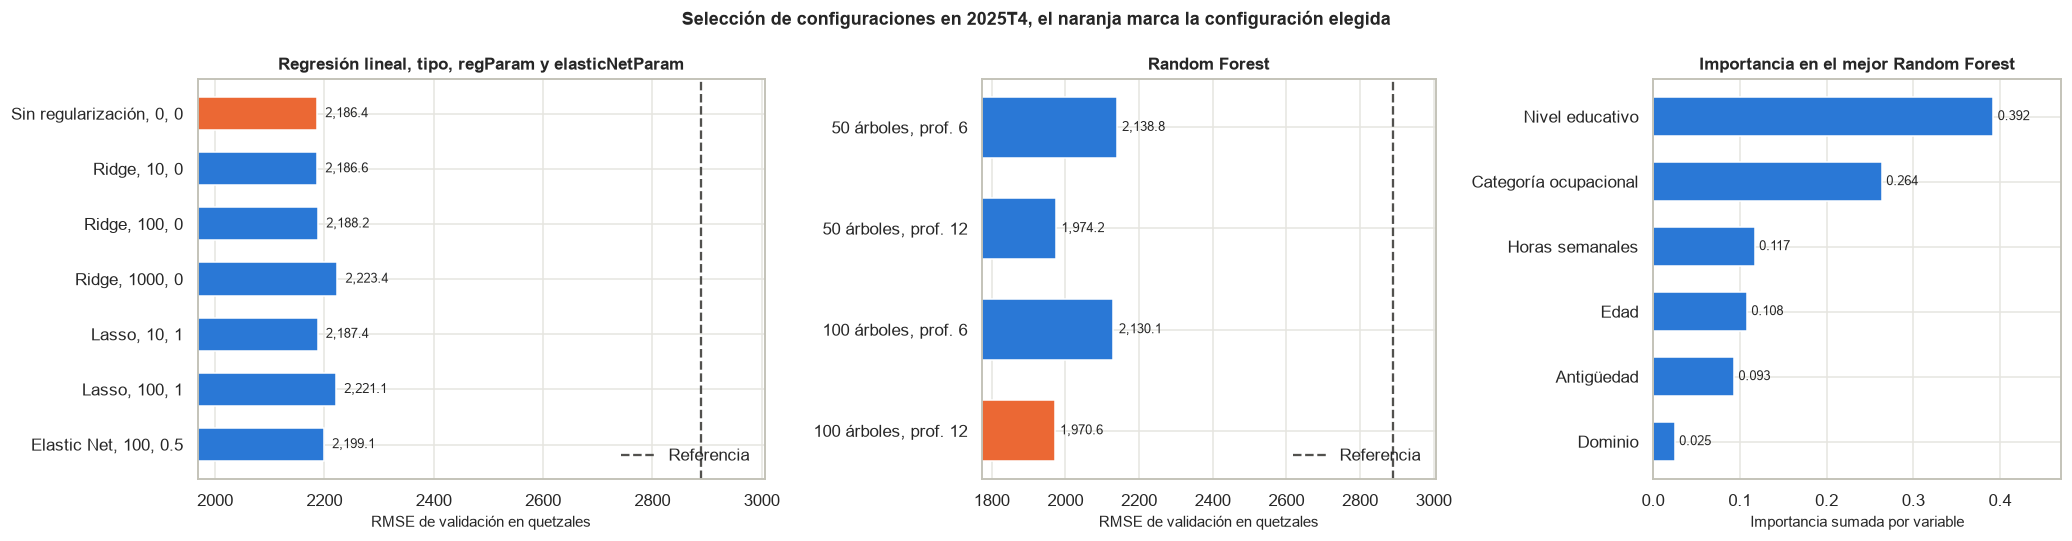

In [56]:
figura, ejes = plt.subplots(1, 3, figsize=(19, 5), gridspec_kw={"width_ratios": [1.25, 1, 0.9]})

etiquetas_lr = [f"{t}, {r:g}, {a:g}" for t, r, a in zip(tabla_lr["tipo"], tabla_lr["regParam"], tabla_lr["elasticNetParam"])]
etiquetas_rf = [f"{n} árboles, prof. {d}" for n, d in zip(tabla_rf["numTrees"], tabla_rf["maxDepth"])]
for eje, tabla, etiquetas, indice_mejor, titulo in [
    (ejes[0], tabla_lr, etiquetas_lr, tabla_lr["RMSE_validacion"].idxmin(), "Regresión lineal, tipo, regParam y elasticNetParam"),
    (ejes[1], tabla_rf, etiquetas_rf, tabla_rf["RMSE_validacion"].idxmin(), "Random Forest"),
]:
    colores = [COLOR_CONTRASTE if i == indice_mejor else COLOR_PRINCIPAL for i in tabla.index]
    eje.barh(etiquetas, tabla["RMSE_validacion"], color=colores, height=0.6)
    eje.axvline(REFERENCIA_VALIDACION["RMSE"], color=COLOR_REFERENCIA, linestyle="--", linewidth=1.5, label="Referencia")
    for y, valor in enumerate(tabla["RMSE_validacion"]):
        eje.text(valor + 15, y, f"{valor:,.1f}", va="center", fontsize=8.5)
    eje.set_xlim(tabla["RMSE_validacion"].min() * 0.9, REFERENCIA_VALIDACION["RMSE"] * 1.04)
    eje.invert_yaxis()
    eje.set_title(titulo, fontsize=11)
    eje.set_xlabel("RMSE de validación en quetzales")
    eje.legend(frameon=False, loc="lower right")

ejes[2].barh(importancia_variable.index, importancia_variable.values, color=COLOR_PRINCIPAL, height=0.6)
ejes[2].invert_yaxis()
for y, valor in enumerate(importancia_variable.values):
    ejes[2].text(valor + 0.005, y, f"{valor:.3f}", va="center", fontsize=8.5)
ejes[2].set_xlim(0, importancia_variable.max() * 1.2)
ejes[2].set_title("Importancia en el mejor Random Forest", fontsize=11)
ejes[2].set_xlabel("Importancia sumada por variable")
figura.suptitle("Selección de configuraciones en 2025T4, el naranja marca la configuración elegida", fontsize=12, fontweight="bold")
plt.tight_layout()
guardar_figura("RMSE de validación por configuración de regresión lineal y Random Forest e importancia de variables")
plt.show()

### 6.2 – Respuestas del Ejercicio 6

**¿Qué algoritmo obtuvo mejores resultados en validación?**

Random Forest con 100 árboles y profundidad 12: MAE de Q1,064.42, RMSE de Q1,970.59 y R² de 0.534, frente a Q1,210.14, Q2,186.42 y 0.426 de la regresión lineal. Reduce el RMSE 9.9% y el MAE 12.0% respecto de la regresión, y 31.8% el RMSE respecto de la referencia. La profundidad pesa mucho más que el número de árboles: pasar de profundidad 6 a 12 baja el RMSE en unos Q160, mientras que duplicar los árboles apenas lo cambia.

**¿Qué diferencias podrían explicar su desempeño?**

La regresión lineal supone efectos aditivos y constantes: una hora adicional vale lo mismo para un profesional que para una trabajadora doméstica. El bosque captura interacciones y umbrales, por ejemplo que la jornada, la educación y la categoría se combinan de forma distinta según el perfil, y por eso las horas ganan importancia, 0.117, pese a su baja correlación marginal. El bosque también acota sus predicciones al rango observado, mientras que la regresión puede predecir salarios negativos. La importancia confirma lo anticipado: nivel educativo, 0.392, y categoría ocupacional, 0.264, concentran dos tercios del poder predictivo. La diferencia entre R² de entrenamiento, 0.585, y de validación, 0.534, muestra un sobreajuste moderado del bosque, mientras que la regresión no sobreajusta.

## Ejercicio 7 – Entrenamiento final y evaluación en 2026

Con la configuración elegida de cada algoritmo se reentrena el pipeline con todo 2025, se predice 2026T1 con las mismas reglas de preparación y ambos modelos se evalúan sobre exactamente los mismos registros, junto con el modelo de referencia.

In [57]:
modelo_lr_final = pipeline_lr(*MEJOR_CONFIG_LR).fit(entrenamiento_final)
modelo_rf_final = pipeline_rf(*MEJOR_CONFIG_RF).fit(entrenamiento_final)
modelo_lr_final.write().overwrite().save(str(DIR_MODELOS / "regresion_lineal_final"))
modelo_rf_final.write().overwrite().save(str(DIR_MODELOS / "random_forest_final"))
media_final = entrenamiento_final.agg(F.mean(OBJETIVO)).first()[0]

evaluacion = (
    modelo_lr_final.transform(prueba).select(*CLAVE, OBJETIVO, *PREDICTORES_NUMERICOS, *PREDICTORES_CATEGORICOS,
                                              F.col("prediccion").alias("prediccion_lr"))
    .join(modelo_rf_final.transform(prueba).select(*CLAVE, F.col("prediccion").alias("prediccion_rf")), on=CLAVE, how="inner")
    .withColumn("prediccion_referencia", F.lit(media_final))
    .withColumn("residuo_lr", F.col(OBJETIVO) - F.col("prediccion_lr"))
    .withColumn("residuo_rf", F.col(OBJETIVO) - F.col("prediccion_rf"))
    .persist()
)
print(f"Registros de prueba elegibles        : {prueba.count():,}")
print(f"Registros evaluados por ambos modelos: {evaluacion.count():,}")
print(f"Salario medio de 2025 usado como referencia: Q{media_final:,.2f}")

metricas_prueba = {
    "Referencia, media de 2025": metricas(evaluacion, "prediccion_referencia"),
    "Regresión lineal": metricas(evaluacion, "prediccion_lr"),
    "Random Forest": metricas(evaluacion, "prediccion_rf"),
}
tabla_prueba = pd.DataFrame(metricas_prueba).T.rename_axis("modelo").reset_index()
tabla_prueba["RMSE_validacion"] = [REFERENCIA_VALIDACION["RMSE"], mejor_lr["RMSE_validacion"], mejor_rf["RMSE_validacion"]]
tabla_prueba["R2_validacion"] = [REFERENCIA_VALIDACION["R2"], mejor_lr["R2_validacion"], mejor_rf["R2_validacion"]]
mostrar(tabla_prueba, decimales={"MAE": 2, "RMSE": 2, "R2": 4, "RMSE_validacion": 2, "R2_validacion": 4})

Registros de prueba elegibles        : 13,258
Registros evaluados por ambos modelos: 13,258
Salario medio de 2025 usado como referencia: Q3,421.68


,modelo,MAE,RMSE,R2,RMSE_validacion,R2_validacion
0,"Referencia, media de 2025","1,718.09","2,871.42",-0.0025,"2,889.57",-0.0031
1,Regresión lineal,"1,240.71","2,163.75",0.4307,"2,186.42",0.4257
2,Random Forest,"1,093.57","1,940.30",0.5422,"1,970.59",0.5335


### 7.1 – Respuestas del Ejercicio 7

**¿Cómo se desempeñan los modelos en 2026?**

Ambos modelos se evaluaron sobre los mismos 13,258 registros. Random Forest es el mejor en las tres métricas: MAE de Q1,093.57, RMSE de Q1,940.30 y R² de 0.542. La regresión lineal obtiene Q1,240.71, Q2,163.75 y 0.431, y la referencia, que predice el salario medio de 2025, obtiene Q1,718.09, Q2,871.42 y -0.003. Frente a la referencia, el RMSE baja 24.6% con la regresión y 32.4% con el bosque; frente a la regresión, el bosque reduce el RMSE 10.3% y el MAE 11.9%.

**¿Se mantiene lo observado en validación?**

Sí. El orden de los modelos se conserva y el R² de prueba es incluso algo mayor que el de validación, 0.542 frente a 0.534 en el bosque y 0.431 frente a 0.426 en la regresión, de modo que los modelos no se degradan al pasar a 2026 pese al aumento del salario medio. Solo la referencia empeora su MAE, de Q1,672.50 a Q1,718.09, porque ese aumento la aleja de los datos. Hay que recordar que el 58.2% de los registros de prueba corresponde a personas ya observadas en 2025.

## Ejercicio 8 – Visualización y análisis de errores

El residuo se define como salario real menos salario predicho, de modo que un residuo positivo indica subestimación y uno negativo sobreestimación. Las figuras usan la misma muestra de 5,000 registros de prueba para ambos modelos, mientras que las métricas por grupo y por percentil se calculan con todos los registros de 2026.

### 8.1 – Salario real frente a predicho y residuos

Los ejes se acotan al percentil 99 de la muestra para que la nube sea legible, y el título indica cuántos puntos quedan fuera.

Registros de la muestra comun de visualizacion: 5,000


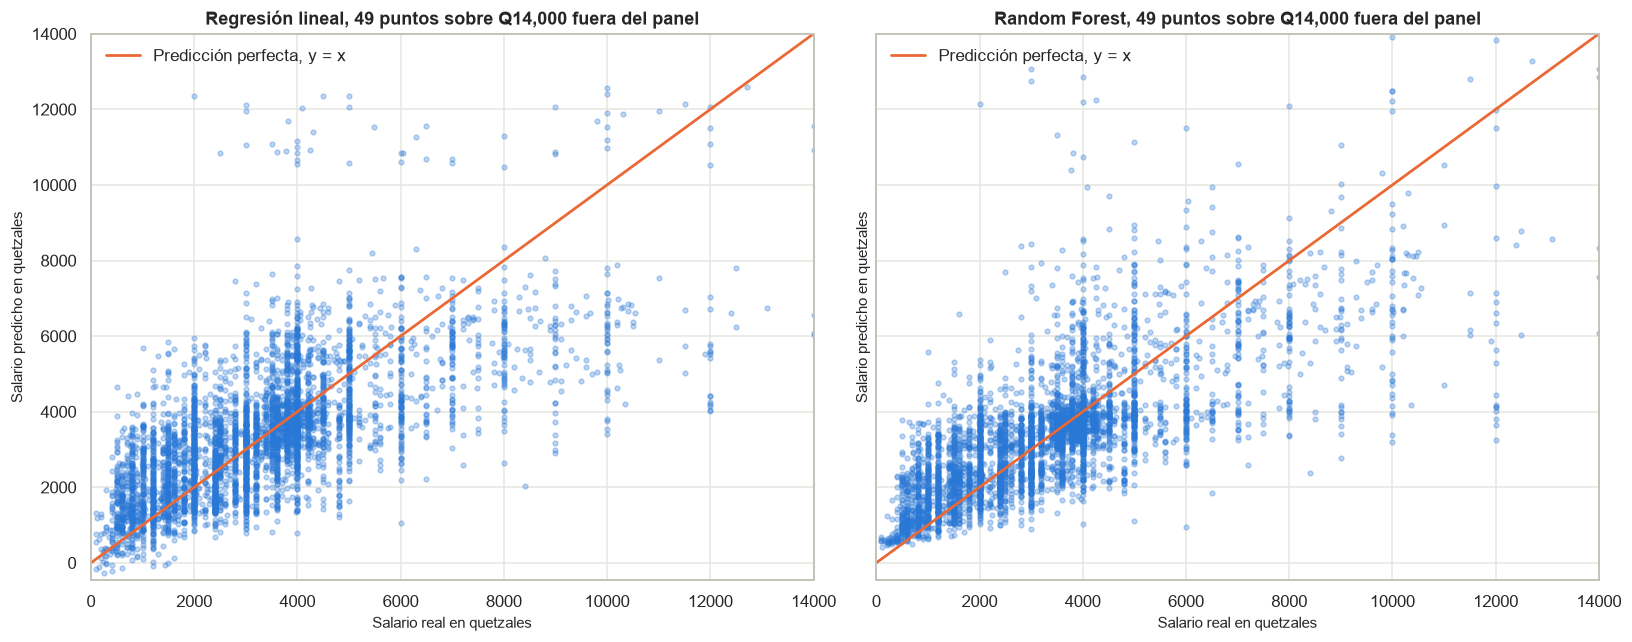

In [58]:
muestra_errores = evaluacion.sample(withReplacement=False, fraction=0.45, seed=SEMILLA).limit(5000).toPandas()
print(f"Registros de la muestra comun de visualizacion: {len(muestra_errores):,}")
MODELOS = [("lr", "Regresión lineal"), ("rf", "Random Forest")]

limite_real = muestra_errores[OBJETIVO].quantile(0.99)
figura, ejes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
for eje, (clave, nombre) in zip(ejes, MODELOS):
    fuera = int((muestra_errores[OBJETIVO] > limite_real).sum())
    eje.scatter(muestra_errores[OBJETIVO], muestra_errores[f"prediccion_{clave}"], s=10, alpha=0.3, color=COLOR_PRINCIPAL)
    eje.plot([0, limite_real], [0, limite_real], color=COLOR_CONTRASTE, linewidth=1.8, label="Predicción perfecta, y = x")
    eje.set_xlim(0, limite_real)
    eje.set_ylim(min(0, muestra_errores[["prediccion_lr", "prediccion_rf"]].min().min()) - 200, limite_real)
    eje.set_title(f"{nombre}, {fuera} puntos sobre Q{limite_real:,.0f} fuera del panel")
    eje.set_xlabel("Salario real en quetzales")
    eje.set_ylabel("Salario predicho en quetzales")
    eje.legend(frameon=False, loc="upper left")
plt.tight_layout()
guardar_figura("Salario real frente a salario predicho en 2026 para regresión lineal y Random Forest, misma muestra")
plt.show()

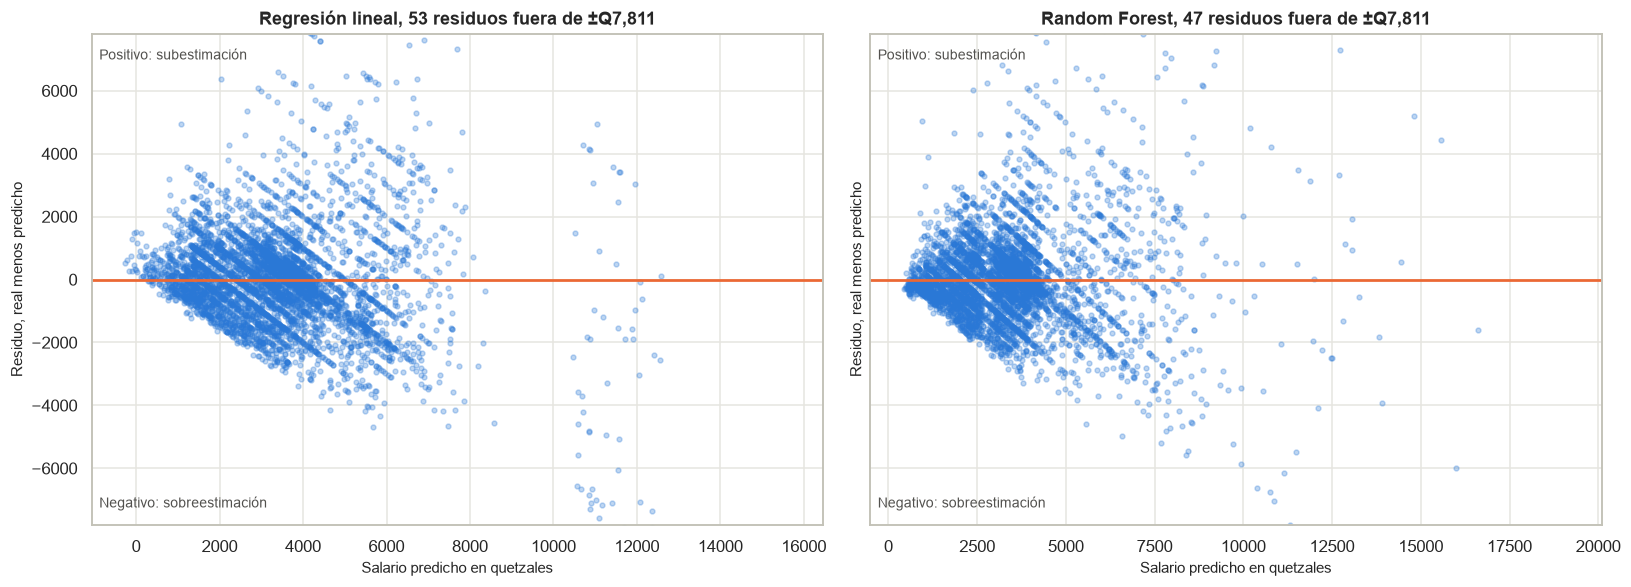

In [59]:
limite_residuo = muestra_errores[["residuo_lr", "residuo_rf"]].abs().stack().quantile(0.99)
figura, ejes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for eje, (clave, nombre) in zip(ejes, MODELOS):
    fuera = int((muestra_errores[f"residuo_{clave}"].abs() > limite_residuo).sum())
    eje.scatter(muestra_errores[f"prediccion_{clave}"], muestra_errores[f"residuo_{clave}"], s=10, alpha=0.3, color=COLOR_PRINCIPAL)
    eje.axhline(0, color=COLOR_CONTRASTE, linewidth=1.8)
    eje.set_ylim(-limite_residuo, limite_residuo)
    eje.set_title(f"{nombre}, {fuera} residuos fuera de ±Q{limite_residuo:,.0f}")
    eje.set_xlabel("Salario predicho en quetzales")
    eje.set_ylabel("Residuo, real menos predicho")
    eje.text(0.01, 0.97, "Positivo: subestimación", transform=eje.transAxes, va="top", fontsize=9, color=COLOR_REFERENCIA)
    eje.text(0.01, 0.03, "Negativo: sobreestimación", transform=eje.transAxes, va="bottom", fontsize=9, color=COLOR_REFERENCIA)
plt.tight_layout()
guardar_figura("Residuos frente al salario predicho en 2026 para regresión lineal y Random Forest, misma muestra")
plt.show()

En ambos modelos la nube está por encima de la diagonal en salarios bajos y por debajo en salarios altos: las predicciones se comprimen hacia el centro. Las franjas verticales reflejan el agrupamiento del salario real en montos redondos. La regresión lineal produce algunas predicciones negativas y un grupo de predicciones cercanas a Q11,000 y Q12,000 que refleja el peso de los coeficientes de posgrado, cualquiera sea el salario real. El bosque se ajusta mejor en el rango medio. En los residuos, la dispersión crece con el salario predicho, lo que indica heterocedasticidad, y la cola positiva de subestimación es más larga que la negativa.

### 8.2 – Error por nivel educativo y por dominio

MAE y error medio de cada modelo por grupo, con todos los registros de prueba. Un error medio positivo indica que el modelo subestima al grupo en promedio.

In [60]:
def error_por_grupo(columna, orden_categorias):
    tabla = (
        evaluacion.groupBy(columna)
        .agg(F.count(F.lit(1)).alias("n"),
             F.mean(OBJETIVO).alias("salario_real_medio"),
             F.mean(F.abs("residuo_lr")).alias("MAE_lr"), F.mean("residuo_lr").alias("error_medio_lr"),
             F.mean(F.abs("residuo_rf")).alias("MAE_rf"), F.mean("residuo_rf").alias("error_medio_rf"))
        .toPandas().set_index(columna).reindex([c for c in orden_categorias])
    )
    return tabla.dropna(subset=["n"]).astype({"n": "int64"}).rename_axis(columna.replace("_etiqueta", "")).reset_index()


decimales_error = {c: 1 for c in ["salario_real_medio", "MAE_lr", "error_medio_lr", "MAE_rf", "error_medio_rf"]}
error_educativo = error_por_grupo("nivel_educativo_etiqueta", ORDEN_EDUCATIVO)
error_dominio = error_por_grupo("dominio_etiqueta", ORDEN_DOMINIO)
print("Error por nivel educativo, prueba 2026")
mostrar(error_educativo, decimales=decimales_error)
print("Error por dominio, prueba 2026")
mostrar(error_dominio, decimales=decimales_error)

Error por nivel educativo, prueba 2026


,nivel_educativo,n,salario_real_medio,MAE_lr,error_medio_lr,MAE_rf,error_medio_rf
0,Ninguno,"1,016","1,884.1",823.5,109.3,640.6,-16.1
1,Preprimaria,80,"2,374.6",735.2,88.8,700.8,-306.4
2,Primaria,"3,957","2,422.7",870.0,54.6,754.5,37.1
3,Básico,"2,164","2,905.5",894.5,127.8,809.8,13.6
4,Diversificado,"4,117","3,924.2","1,109.3",104.0,"1,008.5",197.5
5,Superior,"1,729","6,264.4","2,566.4",295.5,"2,276.4",278.7
6,Maestría,183,"11,290.6","5,552.9",-131.5,"4,601.7",-247.7
7,Doctorado,12,"20,291.7","12,919.3","6,062.7","10,334.8","5,310.1"


Error por dominio, prueba 2026


,dominio,n,salario_real_medio,MAE_lr,error_medio_lr,MAE_rf,error_medio_rf
0,Urbano Metropolitano,"5,632","4,352.3","1,446.1",136.0,"1,298.3",237.2
1,Resto Urbano,"4,846","3,281.6","1,189.6",134.3,"1,040.7",29.6
2,Rural Nacional,"2,780","2,467.7",913.6,65.2,771.0,-11.1


El MAE crece con el nivel educativo porque también crece el salario: de unos Q640 a Q820 sin educación a más de Q2,200 con educación superior y a más de Q10,000 con doctorado. El error medio es pequeño en casi todos los niveles, dentro de unos Q300, salvo en doctorado, que ambos modelos subestiman en más de Q5,000, aunque con solo 12 registros. Por dominio, el área metropolitana tiene el mayor MAE en quetzales, pero en términos relativos el error es parecido entre dominios, alrededor del 30% al 37% del salario medio, y el error medio es pequeño en los tres, entre -Q11 y Q237. Random Forest tiene menor MAE en todos los grupos.

### 8.3 – Errores según el percentil del salario real

Los registros de prueba se agrupan en bandas definidas por percentiles del salario real. Para cada banda se reportan el salario real y predicho promedio, el error medio, el MAE y la proporción del error cuadrático total que aporta, que muestra cuánto pesan los salarios extremos en el RMSE.

In [61]:
PERCENTILES_BANDA = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
NOMBRES_BANDA = ["Hasta p10", "p10 a p25", "p25 a p50", "p50 a p75", "p75 a p90", "p90 a p95", "p95 a p99", "Sobre p99"]
umbrales = evaluacion.agg(F.expr(f"percentile({OBJETIVO}, array({', '.join(map(str, PERCENTILES_BANDA))}))")).first()[0]

expresion_banda = F.lit(len(umbrales))
for posicion in reversed(range(len(umbrales))):
    expresion_banda = F.when(F.col(OBJETIVO) <= umbrales[posicion], F.lit(posicion)).otherwise(expresion_banda)

totales_cuadrados = evaluacion.agg(F.sum(F.col("residuo_lr") ** 2), F.sum(F.col("residuo_rf") ** 2)).first()
bandas = (
    evaluacion.withColumn("banda", expresion_banda)
    .groupBy("banda")
    .agg(F.count(F.lit(1)).alias("n"), F.min(OBJETIVO).alias("salario_minimo"), F.max(OBJETIVO).alias("salario_maximo"),
         F.mean(OBJETIVO).alias("salario_real_medio"),
         F.mean("prediccion_lr").alias("prediccion_media_lr"), F.mean("prediccion_rf").alias("prediccion_media_rf"),
         F.mean("residuo_lr").alias("error_medio_lr"), F.mean("residuo_rf").alias("error_medio_rf"),
         F.mean(F.abs("residuo_lr")).alias("MAE_lr"), F.mean(F.abs("residuo_rf")).alias("MAE_rf"),
         (100 * F.sum(F.col("residuo_lr") ** 2) / F.lit(totales_cuadrados[0])).alias("aporte_error_cuadratico_lr_pct"),
         (100 * F.sum(F.col("residuo_rf") ** 2) / F.lit(totales_cuadrados[1])).alias("aporte_error_cuadratico_rf_pct"))
    .orderBy("banda").toPandas()
)
bandas.insert(0, "banda_percentil", [NOMBRES_BANDA[int(b)] for b in bandas.pop("banda")])
print("Umbrales del salario real de prueba:", ", ".join(f"p{int(p * 100)} = Q{u:,.0f}" for p, u in zip(PERCENTILES_BANDA, umbrales)))
mostrar(bandas, decimales={c: (1 if "pct" in c else 0) for c in bandas.columns if c not in {"banda_percentil", "n"}})

Umbrales del salario real de prueba: p10 = Q1,000, p25 = Q2,000, p50 = Q3,200, p75 = Q4,080, p90 = Q6,000, p95 = Q8,000, p99 = Q15,000


,banda_percentil,n,salario_minimo,salario_maximo,salario_real_medio,prediccion_media_lr,prediccion_media_rf,error_medio_lr,error_medio_rf,MAE_lr,MAE_rf,aporte_error_cuadratico_lr_pct,aporte_error_cuadratico_rf_pct
0,Hasta p10,"1,486",100,"1,000",735,"1,723","1,608",-987,-873,"1,070",888,4.8,4.0
1,p10 a p25,"2,546","1,008","2,000","1,626","2,362","2,320",-736,-694,956,821,6.8,6.4
2,p25 a p50,"2,715","2,010","3,200","2,738","2,899","2,916",-161,-177,852,686,5.9,5.0
3,p50 a p75,"3,200","3,205","4,080","3,770","3,852","3,811",-82,-41,833,713,7.5,8.8
4,p75 a p90,"2,060","4,082","6,000","4,893","4,400","4,378",493,516,"1,176","1,196",7.7,9.5
5,p90 a p95,608,"6,045","8,000","7,225","5,591","5,685","1,634","1,540","2,076","1,973",5.6,6.7
6,p95 a p99,545,"8,060","15,000","10,723","6,631","7,206","4,092","3,517","4,331","3,805",20.6,21.4
7,Sobre p99,98,"15,088","60,000","22,730","8,445","10,398","14,285","12,332","14,285","12,332",41.1,38.0


In [62]:
# distribucion del salario real frente a la de cada prediccion
PERCENTILES_DISTRIBUCION = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
distribuciones = {}
for columna, nombre in [(OBJETIVO, "Salario real"), ("prediccion_lr", "Predicción lineal"), ("prediccion_rf", "Predicción Random Forest")]:
    r = evaluacion.agg(F.expr(f"percentile({columna}, array({', '.join(map(str, PERCENTILES_DISTRIBUCION))}))").alias("p"),
                       F.min(columna).alias("minimo"), F.max(columna).alias("maximo"), F.stddev(columna).alias("desviacion")).first()
    distribuciones[nombre] = {"minimo": r["minimo"], **{f"p{int(p * 100)}": v for p, v in zip(PERCENTILES_DISTRIBUCION, r["p"])},
                              "maximo": r["maximo"], "desviacion": r["desviacion"]}
tabla_distribuciones = pd.DataFrame(distribuciones).T.rename_axis("serie").reset_index()
mostrar(tabla_distribuciones, decimales={c: 0 for c in tabla_distribuciones.columns if c != "serie"})

,serie,minimo,p1,p5,p25,p50,p75,p95,p99,maximo,desviacion
0,Salario real,100,400,720,"2,000","3,200","4,080","8,000","15,000","60,000","2,868"
1,Predicción lineal,-496,403,"1,095","2,178","3,283","4,212","6,426","11,018","15,663","1,826"
2,Predicción Random Forest,431,676,"1,120","2,218","3,301","3,979","7,017","10,662","34,049","1,912"


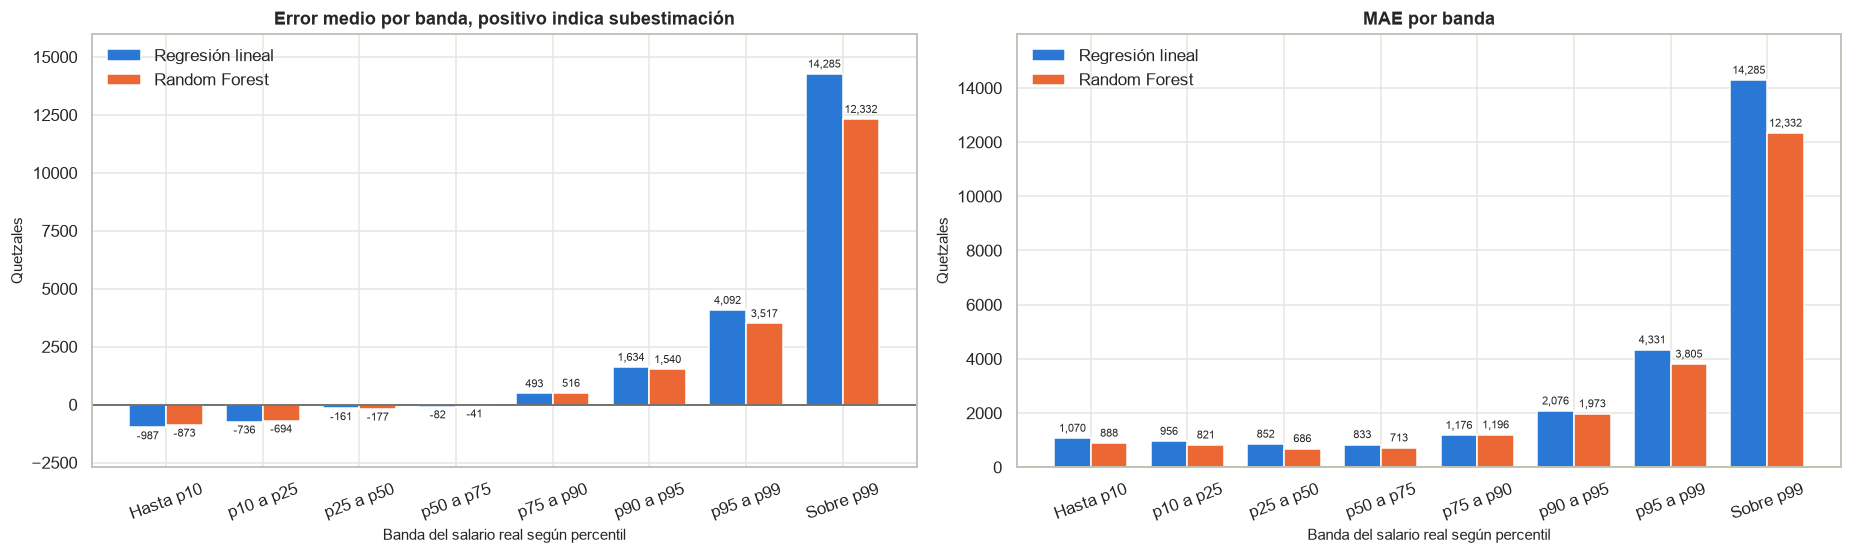

In [63]:
posiciones = np.arange(len(bandas))
ancho = 0.38
figura, ejes = plt.subplots(1, 2, figsize=(17, 5.2))
for eje, metrica, titulo in [(ejes[0], "error_medio", "Error medio por banda, positivo indica subestimación"),
                             (ejes[1], "MAE", "MAE por banda")]:
    for desplazamiento, (clave, nombre), color in [(-ancho / 2, MODELOS[0], COLOR_PRINCIPAL), (ancho / 2, MODELOS[1], COLOR_CONTRASTE)]:
        valores = bandas[f"{metrica}_{clave}"]
        eje.bar(posiciones + desplazamiento, valores, width=ancho, color=color, label=nombre)
        for x, v in zip(posiciones + desplazamiento, valores):
            eje.text(x, v + (150 if v >= 0 else -150), f"{v:,.0f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=7.5)
    eje.axhline(0, color=COLOR_REFERENCIA, linewidth=1)
    eje.set_xticks(posiciones, bandas["banda_percentil"], rotation=20)
    eje.set_title(titulo)
    eje.set_xlabel("Banda del salario real según percentil")
    eje.set_ylabel("Quetzales")
    eje.legend(frameon=False)
    valores_metrica = bandas[[f"{metrica}_lr", f"{metrica}_rf"]]
    margen = valores_metrica.abs().max().max() * 0.12
    minimo = valores_metrica.min().min()
    eje.set_ylim(minimo - margen if minimo < 0 else 0, valores_metrica.max().max() + margen)
plt.tight_layout()
guardar_figura("Error medio y MAE por banda de percentil del salario real en 2026 para ambos modelos")
plt.show()

El error sigue un patrón monotónico con el salario real. Hasta el percentil 50 ambos modelos sobreestiman, más de Q870 en el 10% de salarios más bajos. Cerca de la mediana el error medio es casi cero, y desde el percentil 75 ambos subestiman cada vez más: Q1,634 y Q1,540 entre p90 y p95, Q4,092 y Q3,517 entre p95 y p99, y Q14,285 y Q12,332 en el 1% superior, donde todos los registros quedan subestimados. Ese 5% de registros con salarios sobre Q8,000 genera el 61.7% del error cuadrático de la regresión y el 59.4% del bosque. Las predicciones son además mucho menos dispersas que los datos: su desviación estándar es de Q1,826 y Q1,912 frente a Q2,868, y su percentil 99 es de unos Q11,000 frente a Q15,000.

### 8.4 – Respuestas del Ejercicio 8

**¿Cómo son los errores de los modelos?**

No son homogéneos ni simétricos. Crecen con el nivel del salario, tienen una cola larga de subestimación y siguen un patrón sistemático: los salarios bajos se sobreestiman y los altos se subestiman. No son ruido aleatorio alrededor de cero, sino regresión hacia la media. Random Forest reduce el tamaño de los errores en todos los grupos y bandas, pero mantiene el mismo patrón.

**¿Existe una tendencia a subestimar o sobreestimar los salarios altos?**

Sí, ambos modelos subestiman los salarios altos de forma sistemática, y más cuanto más alto es el salario. Desde el percentil 75 el error medio es positivo y en el 1% superior, con un salario real medio de Q22,730, la predicción media es de Q8,445 en la regresión y Q10,398 en el bosque. Los seis predictores no contienen la información que distingue a quienes ganan mucho, como la ocupación específica, la empresa o el sector, de modo que personas con el mismo perfil observado tienen salarios muy distintos y los modelos, al minimizar el error cuadrático, predicen el promedio de ese perfil.

**¿Qué influencia tienen los salarios extremos?**

Muy grande sobre el RMSE: el 4.85% de registros con salarios sobre Q8,000 explica cerca del 60% del error cuadrático de ambos modelos. Por eso el RMSE debe leerse junto con el MAE, que representa mejor el error típico. Los extremos se conservaron como pide el enunciado; modelar el logaritmo del salario o usar pérdidas robustas podría reducir su influencia, pero queda fuera de la comparación obligatoria.

## Conclusiones

Los cinco archivos de la ENEIC pudieron integrarse en una base consistente después de resolver tres problemas de origen: IV de 2025 tiene otra estructura de columnas, II de 2025 entrega los códigos como texto y TRIMESTRE no identifica el trimestre calendario. La población analítica quedó en 53,025 asalariados en 2025 y 13,258 en 2026, con faltantes estructurales, sin claves repetidas y con un fuerte componente longitudinal.

El salario es muy asimétrico, con media de Q3,422 y mediana de Q3,000, y varía mucho más entre niveles educativos, categorías ocupacionales y dominios que con la edad, la antigüedad o las horas, cuyas correlaciones con el salario no superan 0.18. La segmentación con KMeans identificó cinco perfiles, definidos sobre todo por la etapa de la trayectoria y la jornada. La jornada parcial y la larga permanencia son los rasgos que más cambian el salario típico.

En la predicción, Random Forest superó a la regresión lineal en validación y en la prueba de 2026, con un R² de 0.542 frente a 0.431 y un RMSE 10.3% menor, gracias a su capacidad para capturar interacciones y efectos no lineales. Ambos modelos mejoran claramente al modelo de referencia y se mantuvieron estables al pasar de 2025 a 2026. La regularización no aportó mejoras en la regresión lineal, porque con muchos registros y pocos coeficientes no había sobreajuste que corregir.

La principal limitación es la subestimación sistemática de los salarios altos: el 5% de salarios más altos concentra cerca del 60% del error cuadrático, y en el 1% superior el error medio supera los Q12,000. Con los seis predictores disponibles es posible estimar el salario típico de un perfil, pero no el de una persona concreta con precisión. Los resultados son no ponderados, describen a los registros analizados y no implican relaciones causales ni recomendaciones sobre cuánto debería ganar una persona.